In [37]:
# MU-Glioma-Post data

import os
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

# 1. Setup paths
clinical_data_path = "/Users/kasunachinthaperera/Documents/Final Year Project:Thesis/Data/PKG - MU-Glioma-Post/MU-Glioma-Post_ClinicalData-July2025.xlsx"

# 2. Load Clinical Data
clinical_data = pd.ExcelFile(clinical_data_path)
for sheet in clinical_data.sheet_names:
    df = pd.read_excel(clinical_data_path, sheet_name=sheet)
    print(f"Sheet: {sheet} | Entries: {len(df)} | Columns: {df.columns.tolist()}")


Sheet: Data Dictionary | Entries: 184 | Columns: ['Data Collection Name', 'Data Descriptor /Metadata Name']
Sheet: MU Glioma Post | Entries: 203 | Columns: ['Patient ID', 'Sex at Birth', 'Race', 'Age at diagnosis', 'Primary Diagnosis', 'Grade of Primary Brain Tumor', 'Stereotactic Biopsy before Surgical Resection', 'Progression', 'Time to First Progression (Days)', 'Type of 1st Progression', 'Second Progression/Recurrence', 'Type of 2nd Progression', 'Multiple surgeries', 'Hospice', 'Overall Survival (Death)', 'Number of days from Diagnosis to death (Days)', 'IDH1 mutation', 'IDH2 mutation', '1p/19q', 'ATRX mutation', 'MGMT methylation', 'BRAF V600E mutation', 'TERT promoter mutation', 'Chromosome 7 gain and Chromosome 10 loss', 'H3-3A mutation', 'EGFR amplification', 'PTEN mutation', 'CDKN2A/B deletion', 'TP53 alteration', 'Other mutations/alterations', 'Previous Brain Tumor', 'Type of previous brain tumor', 'Year of previous surgery', 'Grade of Previous brain tumor', 'Number of days 

In [ ]:
# 3. Get Patient IDs from Image Data Directory
image_data_path = "/Users/kasunachinthaperera/Documents/Final Year Project:Thesis/Data/PKG - MU-Glioma-Post/MU-Glioma-Post"

patient_ids = [d for d in os.listdir(image_data_path) 
               if os.path.isdir(os.path.join(image_data_path, d)) and not d.startswith('.')]
patient_ids.sort()

# 4. Iterate through each Patient for timepoint and image verification
for pid in patient_ids:
    patient_folder_path = os.path.join(image_data_path, pid)
    
    # Get Timepoint folders
    timepoints = sorted([t for t in os.listdir(patient_folder_path) 
                        if os.path.isdir(os.path.join(patient_folder_path, t)) and not t.startswith('.')])
    
    print(f"\n" + "="*100)
    print(f"Patient ID: {pid} | Timepoints: {timepoints}")
    print("="*100)

    for timepoint in timepoints:
        timepoint_folder_path = os.path.join(patient_folder_path, timepoint)
        
        # Get all .nii.gz files in the folder
        image_files = sorted([f for f in os.listdir(timepoint_folder_path) 
                              if f.endswith('.nii.gz') and not f.startswith('.')])
        
        if not image_files:
            print(f"   ⚠️ No images found in {timepoint}")
            continue

        # Create a grid to show every image found in the folder
        num_images = len(image_files)
        fig, axes = plt.subplots(1, num_images, figsize=(5 * num_images, 5))
        if num_images == 1: axes = [axes] # Handle single image case
        
        fig.suptitle(f"Patient: {pid}", fontsize=14)

        for i, f_name in enumerate(image_files):
            file_path = os.path.join(timepoint_folder_path, f_name)
            img = nib.load(file_path)
            data = img.get_fdata()
            
            # Show the middle slice (standard for raw data inspection)
            slice_idx = data.shape[2] // 2
            
            axes[i].imshow(np.rot90(data[:, :, slice_idx]), cmap='gray')
            axes[i].set_title(f_name.split('.')[0], fontsize=10)
            axes[i].axis('off')
            
        plt.tight_layout()
        plt.show()

In [3]:
# Segmentation volumes are in a separate Excel file, so we will load that next and filter for the patients we have images for.

# 1. PATHS
segmentation_volume_path = "/Users/kasunachinthaperera/Documents/Final Year Project:Thesis/Data/PKG - MU-Glioma-Post/MU-Glioma-Post_Segmentation_Volumes.xlsx"

# 3. LOAD SEGMENTATION VOLUMES (All Sheets)
segmentation_volumes = pd.ExcelFile(segmentation_volume_path)
volume_data = {}

for sheet in segmentation_volumes.sheet_names:
    # Read the sheet and clean column names
    df = pd.read_excel(segmentation_volume_path, sheet_name=sheet)
    df.columns = df.columns.str.strip()
    
    # Standardize column name to Patient_ID
    if 'Patient ID' in df.columns:
        df = df.rename(columns={'Patient ID': 'Patient_ID'})
        
        # 1. GENERATE TIMEPOINT LABELS
        # Since the ID repeats, cumcount() assigns 0 to the 1st occurrence, 1 to the 2nd, etc.
        # We add 1 and convert to "Timepoint_X" to match your image folder names.
        df['Timepoint_Index'] = df.groupby('Patient_ID').cumcount() + 1
        df['Timepoint'] = "Timepoint_" + df['Timepoint_Index'].astype(str)
        
        # 2. Filter for only the patients found in your image folder (patient_ids list)
        df_filtered = df[df['Patient_ID'].isin(patient_ids)].copy()
        
        # 3. Store in the dictionary
        # We keep Patient_ID as the index, but Timepoint is now an explicit column
        volume_data[sheet] = df_filtered.set_index('Patient_ID')
        
        print(f"{sheet}: Found {len(df_filtered)} total scans for {df_filtered['Patient_ID'].nunique()} unique patients.")

Necrotic Tumor Core (Label1): Found 272 total scans for 119 unique patients.
Tumor Infiltration and Edema: Found 419 total scans for 145 unique patients.
Enhancing Tumor Core (Label3): Found 408 total scans for 144 unique patients.
Resection Cavity (Label4): Found 368 total scans for 135 unique patients.


In [4]:
# Patient objects will be built in the next step, where we will map these volumes to the corresponding timepoints and images for each patient.

# 1. Paths
seg_vol_path = "/Users/kasunachinthaperera/Documents/Final Year Project:Thesis/Data/PKG - MU-Glioma-Post/MU-Glioma-Post_Segmentation_Volumes.xlsx"
image_path = "/Users/kasunachinthaperera/Documents/Final Year Project:Thesis/Data/PKG - MU-Glioma-Post/MU-Glioma-Post"
clinical_data_path = "/Users/kasunachinthaperera/Documents/Final Year Project:Thesis/Data/PKG - MU-Glioma-Post/MU-Glioma-Post_ClinicalData-July2025.xlsx"

# 2. Extract Patient IDs from Image Data (Filter for Directories Only)
patient_ids = sorted([d for d in os.listdir(image_path) 
                     if os.path.isdir(os.path.join(image_path, d)) and not d.startswith('.')])

# 3. Load Segmentation Volumes, Voxels, and Intensity Measures to Map Patients by Sequence Order
print("📊 Extracting volumes, voxels and T1 Contrast, T1 Native, T2 FLAIR T2 Weighted as ordered sequences")
volume_sequences = {}
voxel_sequences = {}
t1c_mean = {}
t1c_stdevs = {}
t1n_mean = {}
t1n_stdevs = {}
t2f_mean = {}
t2f_stdevs = {}
t2w_mean = {}
t2w_stdevs = {}

seg_file = pd.ExcelFile(seg_vol_path)
label_map = {
    "Necrotic Tumor Core (Label1)": "Necrotic",
    "Tumor Infiltration and Edema": "Edema",
    "Enhancing Tumor Core (Label3)": "Enhancing",
    "Resection Cavity (Label4)": "Resection"
}

for sheet in seg_file.sheet_names:
    df = pd.read_excel(seg_vol_path, sheet_name=sheet)
    df.columns = df.columns.str.strip()
    
    if 'Patient ID' in df.columns:
        # Standardize naming
        df = df.rename(columns={'Patient ID': 'Patient_ID'})
        
        # Extract Clean ID (remove suffixes like -Post-treatment_3), and this allows us to group all rows belonging to the same person
        df['Patient_ID_Clean'] = df['Patient_ID'].str.split('-').str[0]
        
        # Identify numerical columns
        voxel_column = 'Number Of Voxels' if 'Number Of Voxels' in df.columns else df.columns[3]
        volume_column = 'Volume (mm^3)' if 'Volume (mm^3)' in df.columns else df.columns[4]
        t1c_mean_column = 'T1 Contrast' if 'T1 Contrast' in df.columns else df.columns[5]
        t1c_stdevs_column = 'T1 Contrast StdDev' if 'T1 Contrast StdDev' in df.columns else df.columns[6]
        t1n_mean_column = 'T1 Native' if 'T1 Native' in df.columns else df.columns[7]
        t1n_stdevs_column = 'T1 Native StdDev' if 'T1 Native StdDev' in df.columns else df.columns[8]
        t2f_mean_column = 'T2 FLAIR' if 'T2 FLAIR' in df.columns else df.columns[9]
        t2f_stdevs_column = 'T2 FLAIR StdDev' if 'T2 FLAIR StdDev' in df.columns else df.columns[10]
        t2w_mean_column = 'T2 Weighted' if 'T2 Weighted' in df.columns else df.columns[11]
        t2w_stdevs_column = 'T2 Weighted StdDev' if 'T2 Weighted StdDev' in df.columns else df.columns[12]

        label_key = label_map.get(sheet, sheet)
        
        # Store data as a list for each patient to preserve the order of visits
        voxel_sequences[label_key] = df.groupby('Patient_ID_Clean')[voxel_column].apply(list).to_dict()
        volume_sequences[label_key] = df.groupby('Patient_ID_Clean')[volume_column].apply(list).to_dict()
        t1c_mean[label_key] = df.groupby('Patient_ID_Clean')[t1c_mean_column].apply(list).to_dict()
        t1c_stdevs[label_key] = df.groupby('Patient_ID_Clean')[t1c_stdevs_column].apply(list).to_dict()
        t1n_mean[label_key] = df.groupby('Patient_ID_Clean')[t1n_mean_column].apply(list).to_dict()
        t1n_stdevs[label_key] = df.groupby('Patient_ID_Clean')[t1n_stdevs_column].apply(list).to_dict()
        t2f_mean[label_key] = df.groupby('Patient_ID_Clean')[t2f_mean_column].apply(list).to_dict()
        t2f_stdevs[label_key] = df.groupby('Patient_ID_Clean')[t2f_stdevs_column].apply(list).to_dict()
        t2w_mean[label_key] = df.groupby('Patient_ID_Clean')[t2w_mean_column].apply(list).to_dict()
        t2w_stdevs[label_key] = df.groupby('Patient_ID_Clean')[t2w_stdevs_column].apply(list).to_dict()

# Load clinical data to map to patients
clinical_df = pd.read_excel(clinical_data_path, sheet_name='MU Glioma Post')
clinical_df.columns = clinical_df.columns.str.strip()
if 'Patient ID' in clinical_df.columns:
    clinical_df = clinical_df.rename(columns={'Patient ID': 'Patient_ID'})
    clinical_df['Patient_ID_Clean'] = clinical_df['Patient_ID'].str.split('-').str[0]
    clinical_data = clinical_df.set_index('Patient_ID_Clean').to_dict(orient='index')
print(f"✅ Clinical data loaded for {len(clinical_data)} patients.")

📊 Extracting volumes, voxels and T1 Contrast, T1 Native, T2 FLAIR T2 Weighted as ordered sequences
✅ Clinical data loaded for 203 patients.


In [5]:
# 4. Construct Unified Patient Objects (SAFE VERSION)
print("🤖 Building integrated Patient objects...")
patient_objects = {}

for pid in patient_ids:
    patient_folder = Path(image_path) / pid
    
    # --- A. CLINICAL DATA INTEGRATION ---
    # Fetch the clean ID to match the clinical dictionary
    clean_id = pid.split('-')[0]
    # Fetch record from the master 'clinical_data' dict created in Step 3
    patient_clinical = clinical_data.get(clean_id, {})

    obj = {
        'Patient_ID': pid,
        'clinical': patient_clinical,
        'timepoints': [],
        'images': {}, 'voxels': {}, 'volumes': {}, 
        't1c_mean': {}, 't1c_stdevs': {},
        't1n_mean': {}, 't1n_stdevs': {},
        't2f_mean': {}, 't2f_stdevs': {},
        't2w_mean': {}, 't2w_stdevs': {},
        'total_volumes': {}, 'total_voxels': {}
    }
    
    if patient_folder.exists():
        tps = sorted([t.name for t in patient_folder.iterdir() if t.is_dir() and not t.name.startswith('.')])
        obj['timepoints'] = tps
        
        for i, tp in enumerate(tps):
            tp_path = patient_folder / tp
            obj['images'][tp] = [str(f) for f in tp_path.glob("*.nii*")]
            
            # Temporary dicts for this specific scan
            tp_volume, tp_voxel = {}, {}
            tp_t1c_mean, tp_t1c_stdevs = {}, {}
            tp_t1n_mean, tp_t1n_stdevs = {}, {}
            tp_t2f_mean, tp_t2f_stdevs = {}, {}
            tp_t2w_mean, tp_t2w_stdevs = {}, {}

            for label in volume_sequences.keys():
                # Fetch sequences from MASTER dicts using unique local names (Safe)
                # This prevents the AttributeError crash
                volume_seq = volume_sequences.get(label, {}).get(pid, [])
                voxel_seq = voxel_sequences.get(label, {}).get(pid, [])
                t1cm_seq = t1c_mean.get(label, {}).get(pid, [])
                t1cs_seq = t1c_stdevs.get(label, {}).get(pid, []) # <--- Master Dict
                t1nm_seq = t1n_mean.get(label, {}).get(pid, [])
                t1ns_seq = t1n_stdevs.get(label, {}).get(pid, [])
                t2fm_seq = t2f_mean.get(label, {}).get(pid, [])
                t2fs_seq = t2f_stdevs.get(label, {}).get(pid, [])
                t2wm_seq = t2w_mean.get(label, {}).get(pid, [])
                t2ws_seq = t2w_stdevs.get(label, {}).get(pid, [])

                # Safety Check: Does this scan index 'i' exist in all data lists?
                if i < len(volume_seq) and i < len(voxel_seq):
                    tp_volume[label] = float(volume_seq[i])
                    tp_voxel[label] = int(voxel_seq[i])
                    
                    # Safe mapping for intensity features
                    if i < len(t1cm_seq): tp_t1c_mean[label] = float(t1cm_seq[i])
                    if i < len(t1cs_seq): tp_t1c_stdevs[label] = float(t1cs_seq[i])
                    if i < len(t1nm_seq): tp_t1n_mean[label] = float(t1nm_seq[i])
                    if i < len(t1ns_seq): tp_t1n_stdevs[label] = float(t1ns_seq[i])
                    if i < len(t2fm_seq): tp_t2f_mean[label] = float(t2fm_seq[i])
                    if i < len(t2fs_seq): tp_t2f_stdevs[label] = float(t2fs_seq[i])
                    if i < len(t2wm_seq): tp_t2w_mean[label] = float(t2wm_seq[i])
                    if i < len(t2ws_seq): tp_t2w_stdevs[label] = float(t2ws_seq[i])

            # Store computed data
            if tp_voxel:
                obj['volumes'][tp] = tp_volume
                obj['voxels'][tp] = tp_voxel
                obj['t1c_mean'][tp] = tp_t1c_mean
                obj['t1c_stdevs'][tp] = tp_t1c_stdevs
                obj['t1n_mean'][tp] = tp_t1n_mean
                obj['t1n_stdevs'][tp] = tp_t1n_stdevs
                obj['t2f_mean'][tp] = tp_t2f_mean
                obj['t2f_stdevs'][tp] = tp_t2f_stdevs
                obj['t2w_mean'][tp] = tp_t2w_mean
                obj['t2w_stdevs'][tp] = tp_t2w_stdevs
                obj['total_volumes'][tp] = sum(tp_volume.values())
                obj['total_voxels'][tp] = sum(tp_voxel.values())

    patient_objects[pid] = obj

print(f"✅ Patient objects built. PatientID_0007 has clinical data: {'Age' in patient_objects['PatientID_0007']['clinical']}")

🤖 Building integrated Patient objects...
✅ Patient objects built. PatientID_0007 has clinical data: False


🧬 FULL DATA AUDIT: PatientID_0003 | 3 Timepoints
   🏥 CLINICAL DATA SNAPSHOT (Static Baseline):
      [Demographics] Age: 57 | Sex: Female | Race: White
      [Molecular]    MGMT methylation: 4 | IDH1 mutation: 0 | IDH2 mutation: 0 | 1p19q: 0 | ATRX mutation: 4 | BRAF V600E mutation: 2 | EGFR amplification: 2 | TERT promoter mutation: 2 | Chromosome 7 gain and Chromosome 10 loss: 2 | H3-3A mutation: 2 | PTEN mutation: 0 | CDKN2A/B deletion: 0 | TP53 alteration: 0 | Other mutations/alterations: nan
      [Diagnosis]    Primary Diagnosis: GBM | Grade of Primary Brain Tumor: 4 | Surg_Days: N/A | Biopsy: 0 | Multiple_Surg: 1 | Previous Brain Tumor: No | Type of previous brain tumor: nan | Year of previous surgery: nan | Grade of Previous brain tumor: nan | Hospice: 1 | Number of days from Diagnosis to date of First Progression: 286.0 | Number of days from Diagnosis to date of Further Progression: nan | Treatment started after 2nd progression: nan | Days from Diagnosis to new treatment afte

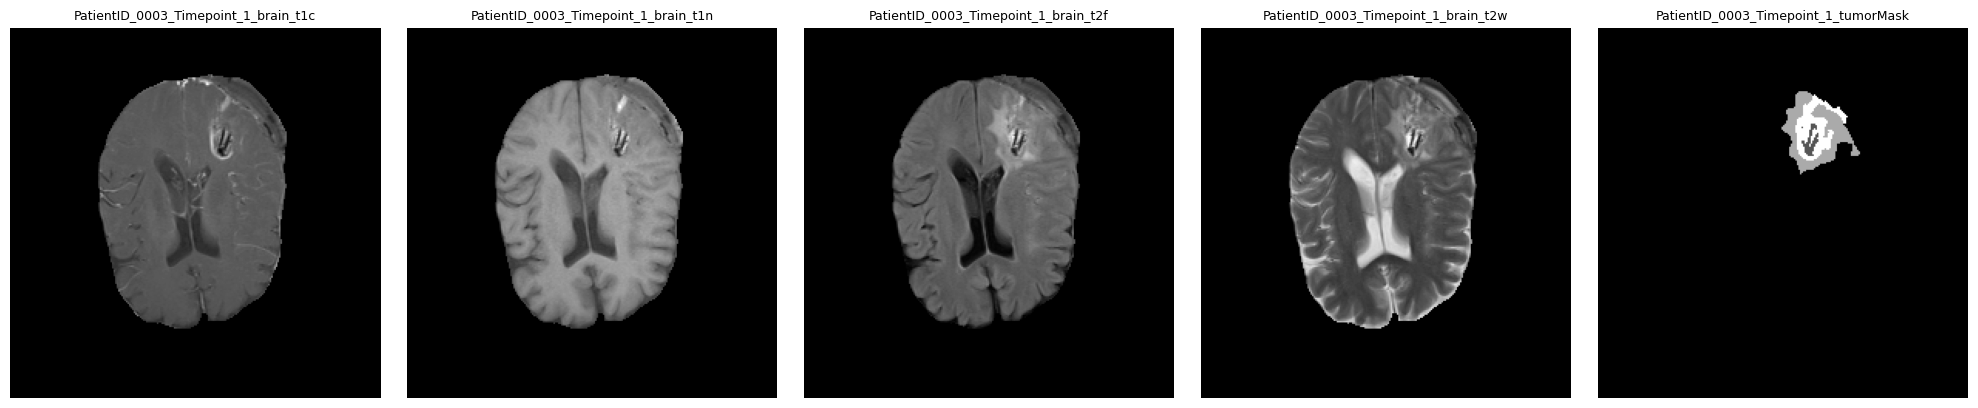

   📊 COMPARTMENTAL ANALYSIS:
      Label        | Volume (mm³) |  Voxel Count |   T1c Mean |  T1c Stdev |   T1n Mean |  T1n Stdev |   T2f Mean |  T2f Stdev |   T2w Mean |  T2w Stdev
      -------------+--------------+--------------+------------+------------+------------+----------------------+------------+------------+-----------
      Necrotic     |      6,510.0 |      6,510.0 |      308.9 |       76.7 |      246.0 |       60.5 |      347.3 |      116.2 |      490.5 |      209.2
      Edema        |     44,251.0 |     44,251.0 |      353.1 |       19.4 |      296.4 |       23.6 |      427.9 |       50.4 |      455.9 |       72.2
      Enhancing    |     33,779.0 |     33,779.0 |      455.8 |       78.8 |      326.0 |       73.8 |      453.4 |       83.8 |      528.5 |      130.8
      Resection    |          --- |          --- |        --- |        --- |        --- |        --- |        --- |        --- |        --- |        ---
   🔬 RADIOMICS (Enhancing Tumor):
      T1C   : mean= 45

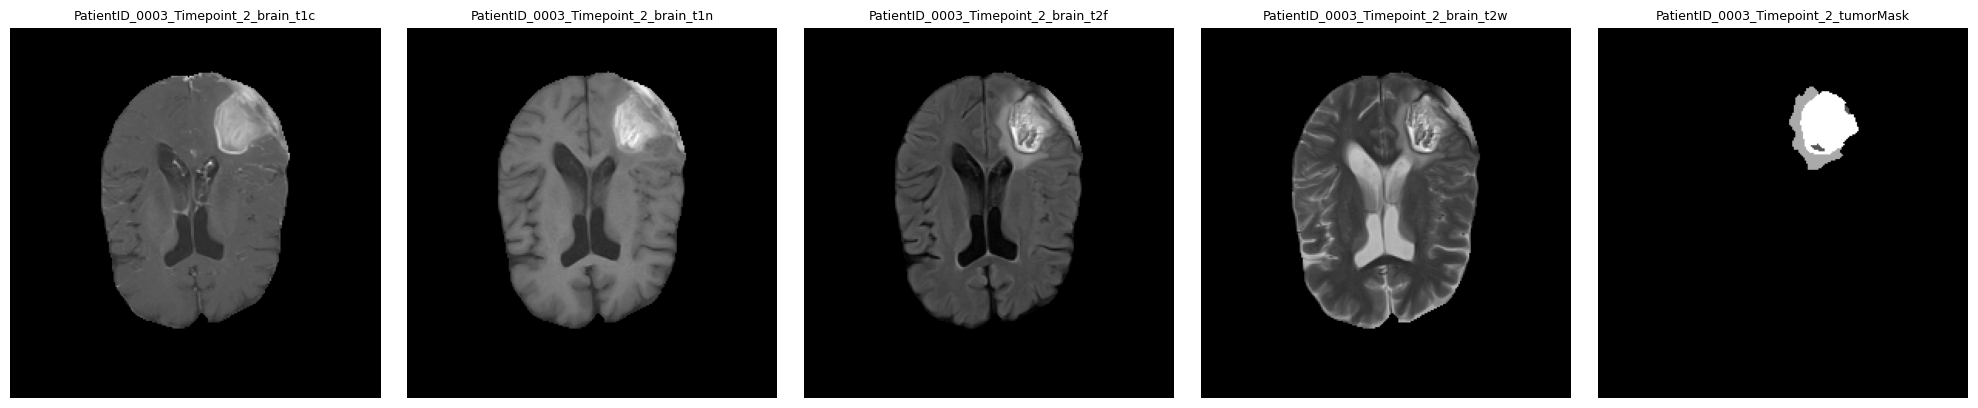

   📊 COMPARTMENTAL ANALYSIS:
      Label        | Volume (mm³) |  Voxel Count |   T1c Mean |  T1c Stdev |   T1n Mean |  T1n Stdev |   T2f Mean |  T2f Stdev |   T2w Mean |  T2w Stdev
      -------------+--------------+--------------+------------+------------+------------+----------------------+------------+------------+-----------
      Necrotic     |      2,813.0 |      2,813.0 |      375.9 |       55.8 |      295.7 |       52.6 |      518.8 |      125.1 |      679.0 |      141.9
      Edema        |     45,757.0 |     45,757.0 |      315.9 |       19.0 |      263.2 |       18.8 |      424.6 |       50.9 |      430.1 |       64.2
      Enhancing    |     37,248.0 |     37,248.0 |      507.1 |       86.2 |      342.2 |       89.0 |      482.4 |      126.1 |      514.0 |      147.4
      Resection    |          --- |          --- |        --- |        --- |        --- |        --- |        --- |        --- |        --- |        ---
   🔬 RADIOMICS (Enhancing Tumor):
      T1C   : mean= 50

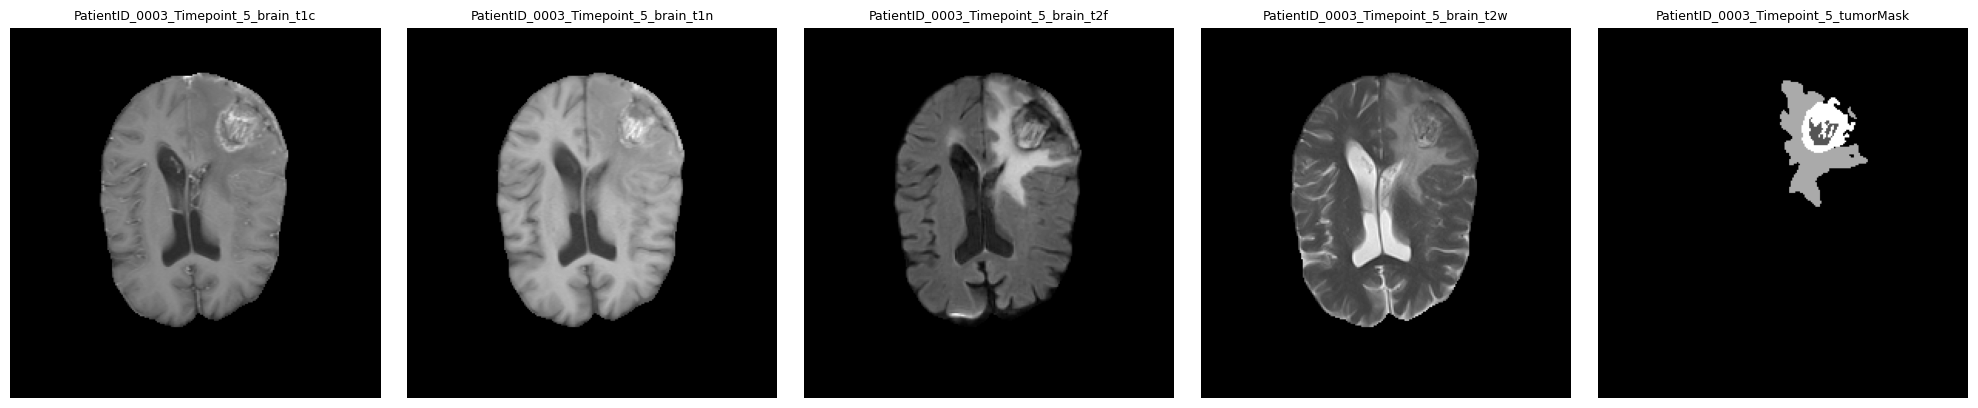

   📊 COMPARTMENTAL ANALYSIS:
      Label        | Volume (mm³) |  Voxel Count |   T1c Mean |  T1c Stdev |   T1n Mean |  T1n Stdev |   T2f Mean |  T2f Stdev |   T2w Mean |  T2w Stdev
      -------------+--------------+--------------+------------+------------+------------+----------------------+------------+------------+-----------
      Necrotic     |      7,317.0 |      7,317.0 |      483.2 |       55.8 |      460.6 |       71.9 |      307.0 |       51.2 |      988.6 |      147.8
      Edema        |    146,633.0 |    146,633.0 |      461.3 |       27.6 |      443.7 |       27.7 |      356.9 |       58.6 |      823.7 |      130.9
      Enhancing    |     39,145.0 |     39,145.0 |      563.3 |       66.9 |      441.1 |       61.2 |      286.8 |       84.8 |      832.7 |      139.2
      Resection    |          --- |          --- |        --- |        --- |        --- |        --- |        --- |        --- |        --- |        ---
   🔬 RADIOMICS (Enhancing Tumor):
      T1C   : mean= 56

In [8]:
# 5. Complete Data Audit: Images + Volumes + Intensity Features

for VHT_Id in list(patient_objects.keys())[:1]:  # Limit to first 3 patients for brevity
    
    if VHT_Id in patient_objects:
        patient = patient_objects[VHT_Id]
        clinical = patient.get('clinical', {})
        
        print(f"🧬 FULL DATA AUDIT: {VHT_Id} | {len(patient['timepoints'])} Timepoints")

        # --- PHASE 1: CLINICAL DATA SNAPSHOT (Patient Baseline - Printed Once) ---
        if clinical:
            print(f"   🏥 CLINICAL DATA SNAPSHOT (Static Baseline):")
            
            # Mapping definitions
            demographics = [('Age', 'Age at diagnosis'), 
                            ('Sex', 'Sex at Birth'), 
                            ('Race', 'Race')]
            molecular = [
                ('MGMT methylation', 'MGMT methylation'), # 0 - No MGMT methylation, 1 - MGMT promoter methylation, 2 - Indeterminate MGMT promoter methylation status, 3 - Unable to assess MGMT promoter methyltion status, 4 - Unknown
                ('IDH1 mutation', 'IDH1 mutation'), # 0 - No IDH1 mutation, 1 - IDH1 mutation is present, 2 - Unknown
                ('IDH2 mutation', 'IDH2 mutation'), # 0 - No IDH2 mutation, 1 - IDH2 mutation is present, 2 - Unknown
                ('1p19q', '1p/19q'), # 0 - No Co-deletion, 1 - Co-deletion, 2 - 19q deletion, 3 - 19q duplication or trisomy, 4 - 19q duplication, 5 - Gain of 19, 6 - 1p deletion, 7 - Tetraploid, 8 - 19q trisomy, 9 - Abnormal karyotype, 10 - Unknown
                ('ATRX mutation', 'ATRX mutation'), # 0 - No ATRX mutation, 1 - ATRX mutation is present, 2 - ATRX is mosaic, 3 - Possible mosaicism, 4 - Unknown
                ('BRAF V600E mutation', 'BRAF V600E mutation'), # 0 - No BRAF V600E mutation, 1 - BRAF V600E mutation is present, 2 - BRAF V600E mutation is unknown
                ('EGFR amplification', 'EGFR amplification'), # 0 - No EGFR amplification, 1 - EGFR amplification, 2 - EGFR amplification is unknown
                ('TERT promoter mutation', 'TERT promoter mutation'), #0 - No TERT promoter mutation, 1 - TERT promoter mutation is present, 2 - TERT promoter mutation is unknown
                ('Chromosome 7 gain and Chromosome 10 loss', 'Chromosome 7 gain and Chromosome 10 loss'), # 0 - No Chromosome 7 gain and Chromosome 10 loss, 1 - Chromosome 7 gain and Chromosome 10 loss, 2 - Chromosome 7 gain and Chromosome 10 loss is unknown
                ('H3-3A mutation', 'H3-3A mutation'), # 0 - No H3-3A mutation, 1 - H3-3A mutation is present, 2 - H3-3A mutation is unknown
                ('PTEN mutation', 'PTEN mutation'), # 0 - No PTEN mutation, 1 - PTEN mutation is present
                ('CDKN2A/B deletion', 'CDKN2A/B deletion'), # 0 - No CDKN2A/B deletion, 1 - CDKN2A/B deletion is present, 2 - CDKN2A/B deletion is unknown
                ('TP53 alteration', 'TP53 alteration'), # 0 - No TP53 alteration, 1 - TP53 alteration is present
                ('Other mutations/alterations', 'Other mutations/alterations') # c-myc reactive/ Gain of 4q11q12, amplification of 12q15q21.1, loss of 13q12.2q14.2, gain of 21, loss of 225. loss of 17/ MSH6, CIC, FAF1/ RB1/ PRDM2, CDK6, MET/ RB1, LRP1B/ Loss of 9p21.3/ LZRT1,  NF1/ NF1, PIK3CA, loss of 9P21.3/ PIK3CA, PTPN11/ RB1, LZTR1, loss of chromosome 13/ RPL5, APC, DDX3X/ APC/ FGFR1/ SEDT2/ PTCH1, RB1, NF1/ NTRK2, RB1/ NF1/ EGFR-SEPT14 fusion/ PIK3R1/ RB1, gain of chromosome 19/ MDM4/ PIK3R1, TSC1, variant of APC/ NF1, PTPN11/ PIK3CA, NRAS/ MTOR, copy number complexity, PDGFRA amplification/ RB1, ARID1A/ H3.3 K27M/ H3 K27M/ KMT2D, complex microarray/ Amplification of MYCN, CDK4/ NF2/ Amplification of PDGFRA and CDK4/ CDK4, NF1/ Likely tetraploid tumor/ MYB, PLAGL1/ MYC/ CTNNB1, EED, CDKN2A/B, PDGFRA/MET/ DICER1, PMS2/ H3K27M/ FGFR2/ FGFR1, PTPN11, gains of chromosomes 6,7,10,11,12,13,18/ PTPN11/ PDGFRA/ PIK3CA, BCOR, SETD2
            ]
            diagnosis = [
                ('Primary Diagnosis', 'Primary Diagnosis'), #Pilocytic astrocytoma, Astrocytoma, Oligodendro-glioma, Neurocytoma, Glioneural, Diffuse glioma, Glioma w/ GBM features, GBM
                ('Grade of Primary Brain Tumor', 'Grade of Primary Brain Tumor'), #Grade 1, Grade 2, Grade 3, Grade 4
                ('Surg_Days', 'Number of days from Diagnosis to First surgery or procedure '), # 
                ('Biopsy', 'Stereotactic Biopsy before Surgical Resection'), # 0 - No stereotactic biopsy before surgery, 1- Stereotactic biopsy done before surgical resection of the tumor
                ('Multiple_Surg', 'Multiple surgeries'), # 0 - No second look or other brain surgeries, 1 - Patient underwent a second look or multiple brain surgeries,
                ('Previous Brain Tumor', 'Previous Brain Tumor'), # Yes, No
                ('Type of previous brain tumor', 'Type of previous brain tumor'), # Indicate the Previous Brain Tumor Type if the patient has
                ('Year of previous surgery', 'Year of previous surgery'), # Indicate the Year when the Previous Brain Tumor has been resected
                ('Grade of Previous brain tumor', 'Grade of Previous brain tumor'), # Grade 2, Grade 3, Grade 4
                ('Hospice', 'Hospice'), # 0: Patient did not receive hospice care, 1: Patient received hospice care
                ('Number of days from Diagnosis to date of First Progression', 'Number of days from Diagnosis to date of First Progression'), # Indicate the # of days from the Time of Diagnosis to the Documented Day of First Progression
                ('Number of days from Diagnosis to date of Further Progression', 'Number of days from Diagnosis to date of Further Progression'), # Indicate the # of days from the Time of Diagnosis to the Documented Day of Further Progression
                ('Treatment started after 2nd progression', 'Treatment started after 2nd progression'), # Indicate if any Type of Treatment after the Documented Day of second Progression
                ('Days from Diagnosis to new treatment after 2nd progression', 'Days from Diagnosis to new treatment after 2nd progression'), # Indicate the # of days from the Time of Diagnosis to the Start Date of New Treatment
                ('Additional Therapy', 'Additional Therapy'), # Indicated if there is any Additional Therapy
                ('Cycle length of Additional Therapy (q days)', 'Cycle length of Additional Therapy (q days)'), # Indicate the # of days for each cycle of Additional Therapy (if any) 
                ('Number of Days from Diagnosis to Starting Additional Therapy', 'Number of Days from Diagnosis to Starting Additional Therapy'), # Indicate the # of days from the Time of Diagnosis to Start the Additional Therapy (if any)
                ('Number of Days from Diagnosis to Complete Additional Therapy', 'Number of Days from Diagnosis to Complete Additional Therapy'), # Indicate the # of days from the Time of Diagnosis to Complete the Additional Therapy (if any)
                ('Number of Cycles of Additional Therapy', 'Number of Cycles of Additional Therapy'), # Indicated the # of Treatment Cycles of the Additional Therapy if multiple
                ('2nd_Additional Therapy', '2nd Additional Therapy'), # Indicated if there is any further Additional Therapy
                ('Cycle length of 2nd_Additional Therapy (q days)', 'Cycle length of 2nd_Additional Therapy (q days)'), # Indicate the # of days for each cycle of the 2nd_Additional Therapy (if any) 
                ('Number of Days from Diagnosis to Starting 2nd_Additional Therapy', 'Number of Days from Diagnosis to Starting 2nd_Additional Therapy'), # Indicate the # of days from the Time of Diagnosis to Start the 2nd_Additional Therapy (if any)
                ('Number of Days from Dagnosis to Complete 2nd_Additional Therapy', 'Number of Days from Dagnosis to Complete 2nd_Additional Therapy'), # Indicate the # of days from the Time of Diagnosis to Complete the 2nd_Additional Therapy (if any)
                ('Number of Cycles of 2nd_Additional Therapy', 'Number of Cycles of 2nd_Additional Therapy'), # Indicated the # of Treatment Cycles of the Additional Therapy if multiple
                ('Immuno therapy', 'Immuno therapy'), # Indicated if the Patient received Immunotherapy (Name of Immunotherapeutic agent) or Not
                ('Cycle length of Immunotherapy (q days)', 'Cycle length of Immunotherapy (q days)'), # Indicate the # of days for each cycle of the Immunotherapy (if any)
                ('Number of Days from Diagnosis to Start Immunotherapy', 'Number of Days from Diagnosis to Start Immunotherapy'), # Indicate the # of days from the Time of Diagnosis to Start the Immunotherapy (if any)
                ('Number of Days from Diagnosis to Complete Immunotherapy', 'Number of Days from Diagnosis to Complete Immunotherapy'), # Indicate the # of days from the Time of Diagnosis to Complete the Immunotherapy (if any)
                ('Number of Cycles of Immunotherapy', 'Number of Cycles of Immunotherapy'), # Indicated the # of Treatment Cycles of the Immunotherapy if multiple
                ('Brachy therapy', 'Brachy therapy'), # Indicated if the Patient received Braachy therapy or Not
                ('Number of Days from Diagnosis to the day of Insertion of Brachytherapy', 'Number of Days from Diagnosis to the day of Insertion of Brachytherapy'), # Indicate the # of days from the Time of Diagnosis to the Documented day of Insertion of the Brachy therapy (if any)
                ('Other Type of Therapy (LITT, more chemo, proton therapy)', 'Other Type of Therapy (LITT, more chemo, proton therapy)'), # Indicated if there is any further Additional Therapy (Type of Treatment e.g. LITT, more chemo, proton therapy) or Not
                ('Number of Days from Diagnosis to Start Other Additional Therapy', 'Number of Days from Diagnosis to Start Other Additional Therapy'), # Indicate the # of days from the Time of Diagnosis to Start any further Additional Therapy (if any)
                ('Number of Days from Diagnosis to Complete Other Additional Therapy', 'Number of Days from Diagnosis to Complete Other Additional Therapy') # Indicate the # of days from the Time of Diagnosis to Complete any further Additional Therapy (if any)
            ]
                
            progression_survival = [
                ('Progression', 'Progression'),# 1: Yes, 0: No
                ('Type of Progression', 'Type of Progression'), # 0: No Progression, 1: Progression by Imaging criteria, 2: Progression by clinical criteria, 3: Progression by both imaging and clinical criteria,
                ('Days_to_Prog', 'Time to First Progression (Days)'), # Time from diagnosis or surgical resection of the tumor to the occurrence of progression in days
                ('Type of 2nd Progression', 'Type of 2nd Progression'), # 0: No Progression, 1: Progression by Imaging criteria, 2: Progression by clinical criteria, 3: Progression by both imaging and clinical criteria
                ('Overall_Survival', 'Overall Survival (Death)'), # 1: Documented patient death in EMR, 0: 0 - No death recorded (Patient alive, lost follow-up or unknown death status)
                ('Days_to_Death', 'Number of days from Diagnosis to death (Days)'), # Number of days from Diagnosis to Death (Days)
                
            ]

            treatment = [
                ('Initial Chemo Therapy', 'Initial Chemo Therapy'), # Yes, NA
                ('Name of initial Chemotherapy', 'Name of initial Chemotherapy'), # The Name of Chemotherapeutic agent
                ('Number of days from Diagnosis to Initial Chemo Therapy Start date', 'Number of days from Diagnosis to Initial Chemo Therapy Start date'), # Indicate the # of days from the Time of Diagnosis to the Initial Chemotherapy
                ('Number of days from Diagnosis to Initial Chemo Therapy end date', 'Number of days from Diagnosis to Initial Chemo Therapy end date'), # Indicate the # of days from the Time of Diagnosis to Complete the Initial Chemotherapy 
                ('Radiation Therapy', 'Radiation Therapy'), # Yes, NA
                ('Number of days from Diagnosis to Radiation Therapy Start date', 'Number of days from Diagnosis to Radiation Therapy Start date'), # Indicate the # of days from the Time of Diagnosis to the Start Date of Radiation Therapy
                ('Number of days from Diagnosis to Radiation Therapy end date', 'Number of days from Diagnosis to Radiation Therapy end date'), # Indicate the # of days from the Time of Diagnosis to the Completion Date of Radiation Therapy
                ('Dose of Radiation Therapy', 'Dose'), # Total Radiation Dose in Gy
                ('Rad_Fractions', 'Number of Fractions') # Indicate the # of fractions of Radiation Therapy

            ]
            temporal_mri = [
                ('MRI_TP1', 'Number of Days from Diagnosis to 1st MRI (Timepoint_1)'),
                ('MRI_TP2', 'Number of Days from Diagnosis to 2nd MRI (Timepoint_2)'),
                ('MRI_TP3', 'Number of Days from Diagnosis to 3rd MRI (Timepoint_3)'),
                ('MRI_TP4', 'Number of Days from Diagnosis to 4th MRI (Timepoint_4)'),
                ('MRI_TP5', 'Number of Days from Diagnosis to 5th MRI (Timepoint_5)'),
                ('MRI_TP6', 'Number of Days from Diagnosis to 6th MRI (Timepoint_6)'),
            ]

            # Formatted Output
            print(f"      [Demographics] " + " | ".join([f"{l}: {clinical.get(c, 'N/A')}" for l, c in demographics]))
            print(f"      [Molecular]    " + " | ".join([f"{l}: {clinical.get(c, 'N/A')}" for l, c in molecular]))
            print(f"      [Diagnosis]    " + " | ".join([f"{l}: {clinical.get(c, 'N/A')}" for l, c in diagnosis]))
            print(f"      [Treatment]    " + " | ".join([f"{l}: {clinical.get(c, 'N/A')}" for l, c in treatment]))
            print(f"      [MRI Timeline] " + " | ".join([f"{l}: {clinical.get(c, 'N/A')} days" for l, c in temporal_mri]))
            print(f"      [Progression]  " + " | ".join([f"{l}: {clinical.get(c, 'N/A')}" for l, c in progression_survival])) 
        else:
            print(f"   🏥 CLINICAL DATA SNAPSHOT: ⚠️ No clinical record found for this Patient ID.")

        # --- PHASE 2: LONGITUDINAL AUDIT (Timepoint Level) ---
        # Sort timepoints to ensure growth rates are calculated chronologically
        sorted_timepoints = sorted(patient['timepoints'])

        for tp_idx, tp in enumerate(sorted_timepoints):
            # tp_idx is the index of the timepoint in the sorted list, tp is the actual timepoint name (e.g. Timepoint_1)
            
            # Identify the Day offset for this specific scan
            tp_num = "".join(filter(str.isdigit, tp))
            days_from_diag = next((v for k, v in clinical.items() if f"Timepoint_{tp_num}" in k), "N/A")
            
            print(f"\n📍 Timepoint {tp_idx+1}: {tp} (Day {days_from_diag} post-diagnosis)")
            
            # --- A. IMAGE VISUALIZATION ---
            images = sorted(patient['images'].get(tp, []))
            if images:
                num_imgs = min(6, len(images))
                fig, axes = plt.subplots(1, num_imgs, figsize=(4*num_imgs, 4))
                if num_imgs == 1: axes = [axes]
                
                for i, img_path in enumerate(images[:num_imgs]):
                    img_obj = nib.load(img_path)
                    data = img_obj.get_fdata()
                    mid_slice = data.shape[2] // 2
                    axes[i].imshow(np.rot90(data[:, :, mid_slice]), cmap='gray')
                    axes[i].set_title(Path(img_path).name.split('.')[0], fontsize=9)
                    axes[i].axis('off')
                plt.tight_layout()
                plt.show()
            
            # --- B. VOLUMES & RADIOMICS ---
            volumes = patient['volumes'].get(tp, {})
            voxels = patient['voxels'].get(tp, {})
            t1c_means = patient['t1c_mean'].get(tp, {})
            t1c_stdevs = patient['t1c_stdevs'].get(tp, {})
            t1n_means = patient['t1n_mean'].get(tp, {})
            t1n_stdevs = patient['t1n_stdevs'].get(tp, {})
            t2f_means = patient['t2f_mean'].get(tp, {})
            t2f_stdevs = patient['t2f_stdevs'].get(tp, {})
            t2w_means = patient['t2w_mean'].get(tp, {})
            t2w_stdevs = patient['t2w_stdevs'].get(tp, {})

            total_vol = patient['total_volumes'].get(tp, 0)
            
            print(f"   📊 COMPARTMENTAL ANALYSIS:")
            print(f"      {'Label':12} | {'Volume (mm³)':>12} | {'Voxel Count':>12} | {'T1c Mean':>10} | {'T1c Stdev':>10} | {'T1n Mean':>10} | {'T1n Stdev':>10} | {'T2f Mean':>10} | {'T2f Stdev':>10} | {'T2w Mean':>10} | {'T2w Stdev':>10}")
            print(f"      {'-'*12}-+-{'-'*12}-+-{'-'*12}-+-{'-'*10}-+-{'-'*10}-+-{'-'*10}-+-{'-'*10}{'-'*10}-+-{'-'*10}-+-{'-'*10}-+-{'-'*10}")
            
            for label in ['Necrotic', 'Edema', 'Enhancing', 'Resection']:
                vol = volumes.get(label, 0)
                vox = voxels.get(label, 0)
                m_t1c = t1c_means.get(label, 0)
                stdev_t1c = t1c_stdevs.get(label, 0)
                m_t1n = t1n_means.get(label, 0)
                stdev_t1n = t1n_stdevs.get(label, 0)
                m_t2f = t2f_means.get(label, 0)
                stdev_t2f = t2f_stdevs.get(label, 0)
                m_t2w = t2w_means.get(label, 0)
                stdev_t2w = t2w_stdevs.get(label, 0)
                if vol > 0:
                    print(f"      {label:12} | {vol:>12,.1f} | {vox:>12,.1f} | {m_t1c:>10.1f} | {stdev_t1c:>10.1f} | {m_t1n:>10.1f} | {stdev_t1n:>10.1f} | {m_t2f:>10.1f} | {stdev_t2f:>10.1f} | {m_t2w:>10.1f} | {stdev_t2w:>10.1f}" )
                else:
                    print(f"      {label:12} | {'---':>12} | {'---':>12} | {'---':>10} | {'---':>10} | {'---':>10} | {'---':>10} | {'---':>10} | {'---':>10} | {'---':>10} | {'---':>10}")
            """print(f"      {'TOTAL':12} | {total_vol:>12,.1f} | {'---':>12} | {'---':>10} | {'---':>10} | {'---':>10}")"""

            # --- C. RADIOMICS INTENSITY FEATURES ---
            print(f"   🔬 RADIOMICS (Enhancing Tumor):")
            for mod in ['t1c', 't1n', 't2f', 't2w']:
                mean = patient[f'{mod}_mean'].get(tp, {}).get('Enhancing', 'N/A')
                stdev = patient[f'{mod}_stdevs'].get(tp, {}).get('Enhancing', 'N/A')
                if mean != 'N/A':
                    print(f"      {mod.upper():6}: mean={mean:>6.1f} | stdev={stdev:>6.1f}")
            
            # --- D. GROWTH TREND ---
            if tp_idx > 0:
                prev_tp = sorted_timepoints[tp_idx-1]
                prev_vol = patient['total_volumes'].get(prev_tp, 0)
                if prev_vol > 0:
                    growth_rate = (total_vol - prev_vol) / prev_vol * 100
                    print(f"\n   📈 GROWTH vs {prev_tp}: {growth_rate:+6.1f}%")
            
            print("-" * 100)

    else:
        print(f"❌ Error: {VHT_Id} not found in patient objects.")



🔍 Clinical DATA SUMMARY FOR PatientID_0003 🔍
      [Demographics] Age: 57 | Sex: Female | Race: White
      [Molecular]    MGMT methylation: 4 | IDH1 mutation: 0 | IDH2 mutation: 0 | 1p19q: 0 | ATRX mutation: 4 | BRAF V600E mutation: 2 | EGFR amplification: 2 | TERT promoter mutation: 2 | Chromosome 7 gain and Chromosome 10 loss: 2 | H3-3A mutation: 2 | PTEN mutation: 0 | CDKN2A/B deletion: 0 | TP53 alteration: 0 | Other mutations/alterations: nan
      [Diagnosis]    Primary Diagnosis: GBM | Grade of Primary Brain Tumor: 4 | Surg_Days: N/A | Biopsy: 0 | Multiple_Surg: 1 | Previous Brain Tumor: No | Type of previous brain tumor: nan | Year of previous surgery: nan | Grade of Previous brain tumor: nan | Hospice: 1 | Number of days from Diagnosis to date of First Progression: 286.0 | Number of days from Diagnosis to date of Further Progression: nan | Treatment started after 2nd progression: nan | Days from Diagnosis to new treatment after 2nd progression: N/A | Additional Therapy: Temo

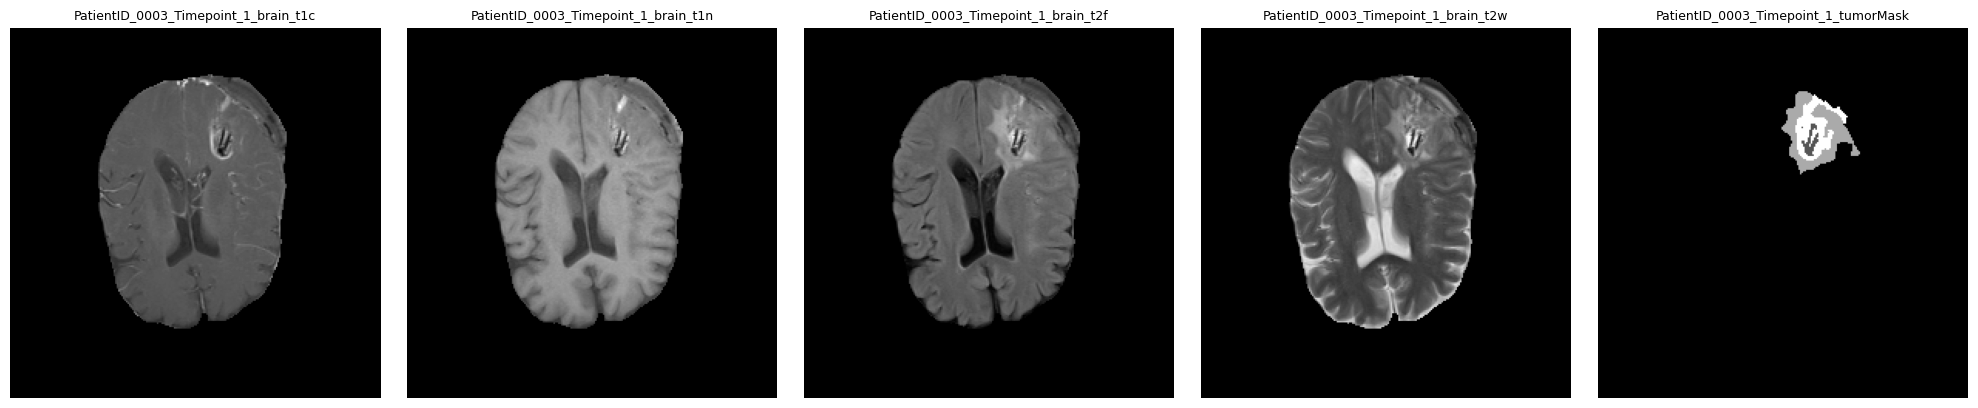

   📊 COMPARTMENTAL ANALYSIS:
      Label        | Volume (mm³) |  Voxel Count |   T1c Mean |  T1c Stdev |   T1n Mean |  T1n Stdev |   T2f Mean |  T2f Stdev |   T2w Mean |  T2w Stdev
      -------------+--------------+--------------+------------+------------+------------+----------------------+------------+------------+-----------
      Necrotic     |      6,510.0 |      6,510.0 |      308.9 |       76.7 |      246.0 |       60.5 |      347.3 |      116.2 |      490.5 |      209.2
      Edema        |     44,251.0 |     44,251.0 |      353.1 |       19.4 |      296.4 |       23.6 |      427.9 |       50.4 |      455.9 |       72.2
      Enhancing    |     33,779.0 |     33,779.0 |      455.8 |       78.8 |      326.0 |       73.8 |      453.4 |       83.8 |      528.5 |      130.8
      Resection    |          --- |          --- |        --- |        --- |        --- |        --- |        --- |        --- |        --- |        ---
   🔬 RADIOMICS (Enhancing Tumor):
      T1C   : mean= 45

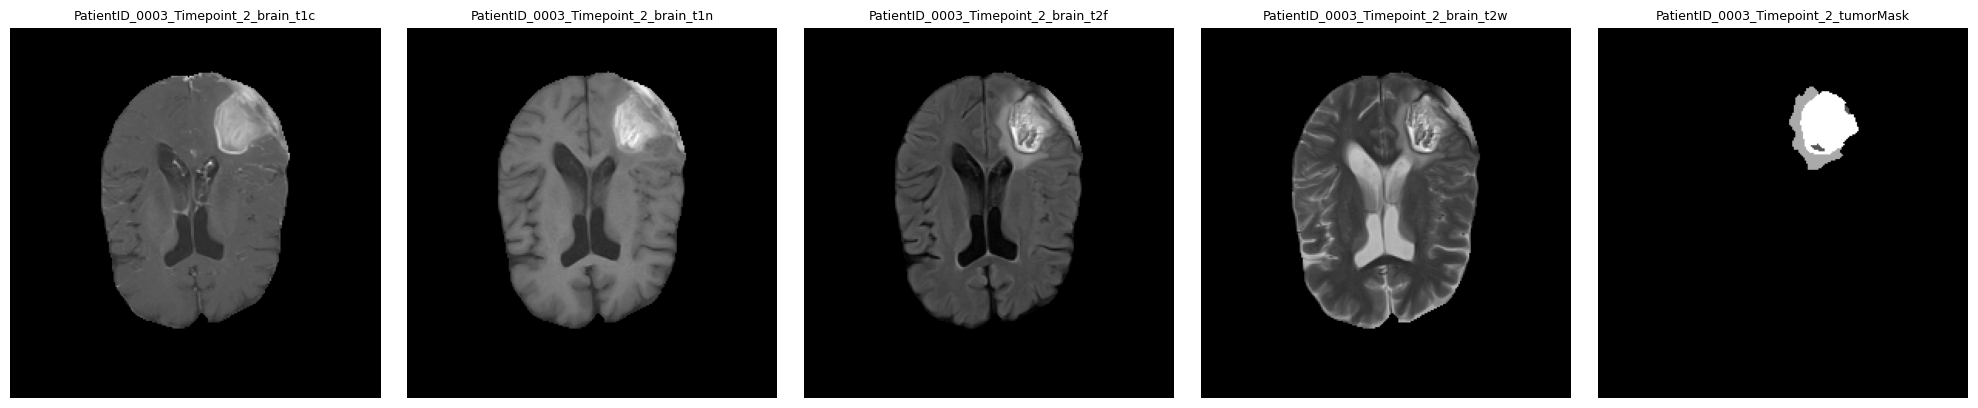

   📊 COMPARTMENTAL ANALYSIS:
      Label        | Volume (mm³) |  Voxel Count |   T1c Mean |  T1c Stdev |   T1n Mean |  T1n Stdev |   T2f Mean |  T2f Stdev |   T2w Mean |  T2w Stdev
      -------------+--------------+--------------+------------+------------+------------+----------------------+------------+------------+-----------
      Necrotic     |      2,813.0 |      2,813.0 |      375.9 |       55.8 |      295.7 |       52.6 |      518.8 |      125.1 |      679.0 |      141.9
      Edema        |     45,757.0 |     45,757.0 |      315.9 |       19.0 |      263.2 |       18.8 |      424.6 |       50.9 |      430.1 |       64.2
      Enhancing    |     37,248.0 |     37,248.0 |      507.1 |       86.2 |      342.2 |       89.0 |      482.4 |      126.1 |      514.0 |      147.4
      Resection    |          --- |          --- |        --- |        --- |        --- |        --- |        --- |        --- |        --- |        ---
   🔬 RADIOMICS (Enhancing Tumor):
      T1C   : mean= 50

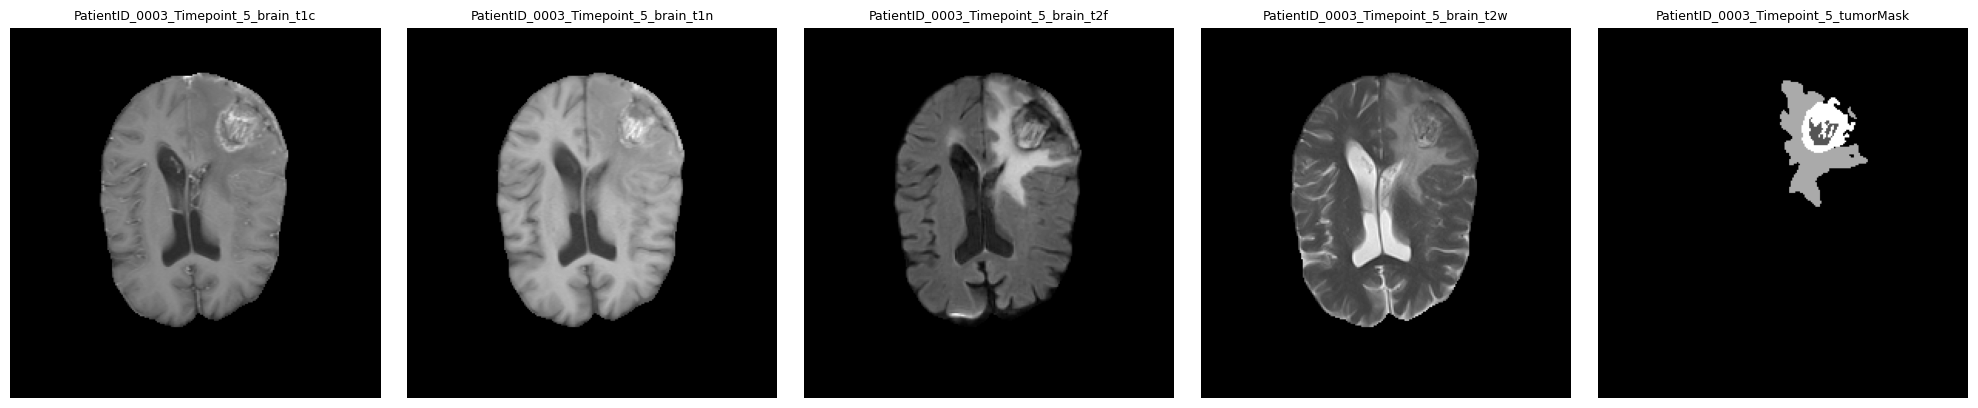

   📊 COMPARTMENTAL ANALYSIS:
      Label        | Volume (mm³) |  Voxel Count |   T1c Mean |  T1c Stdev |   T1n Mean |  T1n Stdev |   T2f Mean |  T2f Stdev |   T2w Mean |  T2w Stdev
      -------------+--------------+--------------+------------+------------+------------+----------------------+------------+------------+-----------
      Necrotic     |      7,317.0 |      7,317.0 |      483.2 |       55.8 |      460.6 |       71.9 |      307.0 |       51.2 |      988.6 |      147.8
      Edema        |    146,633.0 |    146,633.0 |      461.3 |       27.6 |      443.7 |       27.7 |      356.9 |       58.6 |      823.7 |      130.9
      Enhancing    |     39,145.0 |     39,145.0 |      563.3 |       66.9 |      441.1 |       61.2 |      286.8 |       84.8 |      832.7 |      139.2
      Resection    |          --- |          --- |        --- |        --- |        --- |        --- |        --- |        --- |        --- |        ---
   🔬 RADIOMICS (Enhancing Tumor):
      T1C   : mean= 56

In [9]:
for VHT_Id in list(patient_objects.keys())[:1]:  # Limit to first 3 patients for brevity
    
    if VHT_Id in patient_objects:
        clinical = patient.get('clinical', {})

        print(f"\n\n🔍 Clinical DATA SUMMARY FOR {VHT_Id} 🔍")

    # Formatted Output
        print(f"      [Demographics] " + " | ".join([f"{l}: {clinical.get(c, 'N/A')}" for l, c in demographics]))
        print(f"      [Molecular]    " + " | ".join([f"{l}: {clinical.get(c, 'N/A')}" for l, c in molecular]))
        print(f"      [Diagnosis]    " + " | ".join([f"{l}: {clinical.get(c, 'N/A')}" for l, c in diagnosis]))
        print(f"      [Treatment]    " + " | ".join([f"{l}: {clinical.get(c, 'N/A')}" for l, c in treatment]))
        print(f"      [MRI Timeline] " + " | ".join([f"{l}: {clinical.get(c, 'N/A')} days" for l, c in temporal_mri]))
        print(f"      [Progression]  " + " | ".join([f"{l}: {clinical.get(c, 'N/A')}" for l, c in progression_survival])) 
    
        patient = patient_objects[VHT_Id]
        clinical = patient.get('clinical', {})
        
        print(f"🧬 FULL DATA AUDIT: {VHT_Id} | {len(patient['timepoints'])} Timepoints")

        if clinical:
            print(f"   🏥 CLINICAL DATA SNAPSHOT (Static Baseline):")

        # --- PHASE 2: LONGITUDINAL AUDIT (Timepoint Level) ---
        sorted_timepoints = sorted(patient['timepoints'])

        for tp_idx, tp in enumerate(sorted_timepoints):
            
            # Identify the Day offset for this specific scan
            tp_num = "".join(filter(str.isdigit, tp))
            days_from_diag = next((v for k, v in clinical.items() if f"Timepoint_{tp_num}" in k), "N/A")
            
            print(f"\n📍 Timepoint {tp_idx+1}: {tp} (Day {days_from_diag} post-diagnosis)")
            
            # --- A. IMAGE VISUALIZATION ---
            images = sorted(patient['images'].get(tp, []))
            if images:
                num_imgs = min(6, len(images))
                fig, axes = plt.subplots(1, num_imgs, figsize=(4*num_imgs, 4))
                if num_imgs == 1: axes = [axes]
                
                for i, img_path in enumerate(images[:num_imgs]):
                    img_obj = nib.load(img_path)
                    data = img_obj.get_fdata()
                    mid_slice = data.shape[2] // 2
                    axes[i].imshow(np.rot90(data[:, :, mid_slice]), cmap='gray')
                    axes[i].set_title(Path(img_path).name.split('.')[0], fontsize=9)
                    axes[i].axis('off')
                plt.tight_layout()
                plt.show()
            
            # --- B. VOLUMES & RADIOMICS ---
            volumes = patient['volumes'].get(tp, {})
            voxels = patient['voxels'].get(tp, {})
            t1c_means = patient['t1c_mean'].get(tp, {})
            t1c_stdevs = patient['t1c_stdevs'].get(tp, {})
            t1n_means = patient['t1n_mean'].get(tp, {})
            t1n_stdevs = patient['t1n_stdevs'].get(tp, {})
            t2f_means = patient['t2f_mean'].get(tp, {})
            t2f_stdevs = patient['t2f_stdevs'].get(tp, {})
            t2w_means = patient['t2w_mean'].get(tp, {})
            t2w_stdevs = patient['t2w_stdevs'].get(tp, {})

            total_vol = patient['total_volumes'].get(tp, 0)
            
            print(f"   📊 COMPARTMENTAL ANALYSIS:")
            print(f"      {'Label':12} | {'Volume (mm³)':>12} | {'Voxel Count':>12} | {'T1c Mean':>10} | {'T1c Stdev':>10} | {'T1n Mean':>10} | {'T1n Stdev':>10} | {'T2f Mean':>10} | {'T2f Stdev':>10} | {'T2w Mean':>10} | {'T2w Stdev':>10}")
            print(f"      {'-'*12}-+-{'-'*12}-+-{'-'*12}-+-{'-'*10}-+-{'-'*10}-+-{'-'*10}-+-{'-'*10}{'-'*10}-+-{'-'*10}-+-{'-'*10}-+-{'-'*10}")
            
            for label in ['Necrotic', 'Edema', 'Enhancing', 'Resection']:
                vol = volumes.get(label, 0)
                vox = voxels.get(label, 0)
                m_t1c = t1c_means.get(label, 0)
                stdev_t1c = t1c_stdevs.get(label, 0)
                m_t1n = t1n_means.get(label, 0)
                stdev_t1n = t1n_stdevs.get(label, 0)
                m_t2f = t2f_means.get(label, 0)
                stdev_t2f = t2f_stdevs.get(label, 0)
                m_t2w = t2w_means.get(label, 0)
                stdev_t2w = t2w_stdevs.get(label, 0)
                if vol > 0:
                    print(f"      {label:12} | {vol:>12,.1f} | {vox:>12,.1f} | {m_t1c:>10.1f} | {stdev_t1c:>10.1f} | {m_t1n:>10.1f} | {stdev_t1n:>10.1f} | {m_t2f:>10.1f} | {stdev_t2f:>10.1f} | {m_t2w:>10.1f} | {stdev_t2w:>10.1f}" )
                else:
                    print(f"      {label:12} | {'---':>12} | {'---':>12} | {'---':>10} | {'---':>10} | {'---':>10} | {'---':>10} | {'---':>10} | {'---':>10} | {'---':>10} | {'---':>10}")
            """print(f"      {'TOTAL':12} | {total_vol:>12,.1f} | {'---':>12} | {'---':>10} | {'---':>10} | {'---':>10}")"""

            # --- C. RADIOMICS INTENSITY FEATURES ---
            print(f"   🔬 RADIOMICS (Enhancing Tumor):")
            for mod in ['t1c', 't1n', 't2f', 't2w']:
                mean = patient[f'{mod}_mean'].get(tp, {}).get('Enhancing', 'N/A')
                stdev = patient[f'{mod}_stdevs'].get(tp, {}).get('Enhancing', 'N/A')
                if mean != 'N/A':
                    print(f"      {mod.upper():6}: mean={mean:>6.1f} | stdev={stdev:>6.1f}")
            
            # --- D. GROWTH TREND ---
            if tp_idx > 0:
                prev_tp = sorted_timepoints[tp_idx-1]
                prev_vol = patient['total_volumes'].get(prev_tp, 0)
                if prev_vol > 0:
                    growth_rate = (total_vol - prev_vol) / prev_vol * 100
                    print(f"\n   📈 GROWTH vs {prev_tp}: {growth_rate:+6.1f}%")
            
            print("-" * 100)

    else:
        print(f"❌ Error: {VHT_Id} not found in patient objects.")


 PatientID_0003 - 3D TUMOR ARCHITECTURE & RATE ANALYSIS 

 Timepoint_1 | Day 90.0
   📊 COMPARTMENTAL ANALYSIS (Radiomics):
      Label        |  Vol (mm³) |  Vox Count |      T1c (μ±σ) |      T1n (μ±σ) |      T2f (μ±σ) |      T2w (μ±σ)
      -------------+------------+------------+----------------+----------------+----------------+---------------
      Necrotic     |     6510.0 |       6510 |  308.9(±76.7)  |  246.0(±60.5)  |  347.3(±116.2) |  490.5(±209.2)
      Edema        |    44251.0 |      44251 |  353.1(±19.4)  |  296.4(±23.6)  |  427.9(±50.4)  |  455.9(±72.2) 
      Enhancing    |    33779.0 |      33779 |  455.8(±78.8)  |  326.0(±73.8)  |  453.4(±83.8)  |  528.5(±130.8)
      Resection    |        --- |        --- |            --- |            --- |            --- |            ---

   🔍 IMAGE VALIDATION (Pixels vs CSV):
      Necrotic     | Pixels:     6510 | Calc_Vol:     6510.0 | CSV_Vol:     6510.0
      Edema        | Pixels:    44251 | Calc_Vol:    44251.0 | CSV_Vol:    

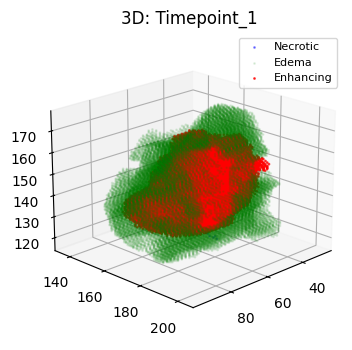

   Baseline established. Kinetics will be calculated at next timepoint.

 Timepoint_2 | Day 146.0
   📊 COMPARTMENTAL ANALYSIS (Radiomics):
      Label        |  Vol (mm³) |  Vox Count |      T1c (μ±σ) |      T1n (μ±σ) |      T2f (μ±σ) |      T2w (μ±σ)
      -------------+------------+------------+----------------+----------------+----------------+---------------
      Necrotic     |     2813.0 |       2813 |  375.9(±55.8)  |  295.7(±52.6)  |  518.8(±125.1) |  679.0(±141.9)
      Edema        |    45757.0 |      45757 |  315.9(±19.0)  |  263.2(±18.8)  |  424.6(±50.9)  |  430.1(±64.2) 
      Enhancing    |    37248.0 |      37248 |  507.1(±86.2)  |  342.2(±89.0)  |  482.4(±126.1) |  514.0(±147.4)
      Resection    |        --- |        --- |            --- |            --- |            --- |            ---

   🔍 IMAGE VALIDATION (Pixels vs CSV):
      Necrotic     | Pixels:     2813 | Calc_Vol:     2813.0 | CSV_Vol:     2813.0
      Edema        | Pixels:    45757 | Calc_Vol:    45757.0

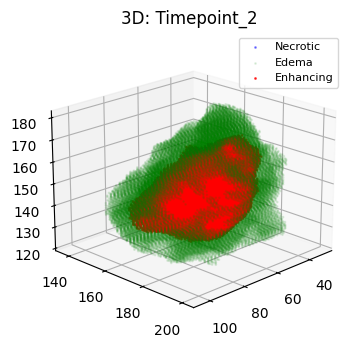

   KINETIC VELOCITY (Change per Day) over 56.0 days:
      Label        |       ΔVol |        ΔT1c(μ|σ) |        ΔT1n(μ|σ) |        ΔT2f(μ|σ) |        ΔT2w(μ|σ)
      -------------+------------+------------------+------------------+------------------+-----------------
      Necrotic     |     -66.02 |    1.20|  -0.37  |    0.89|  -0.14  |    3.06|   0.16  |    3.37|  -1.20 
      Edema        |      26.89 |   -0.66|  -0.01  |   -0.59|  -0.09  |   -0.06|   0.01  |   -0.46|  -0.14 
      Enhancing    |      61.95 |    0.92|   0.13  |    0.29|   0.27  |    0.52|   0.76  |   -0.26|   0.30 

 Timepoint_5 | Day 286.0
   📊 COMPARTMENTAL ANALYSIS (Radiomics):
      Label        |  Vol (mm³) |  Vox Count |      T1c (μ±σ) |      T1n (μ±σ) |      T2f (μ±σ) |      T2w (μ±σ)
      -------------+------------+------------+----------------+----------------+----------------+---------------
      Necrotic     |     7317.0 |       7317 |  483.2(±55.8)  |  460.6(±71.9)  |  307.0(±51.2)  |  988.6(±147.8)
 

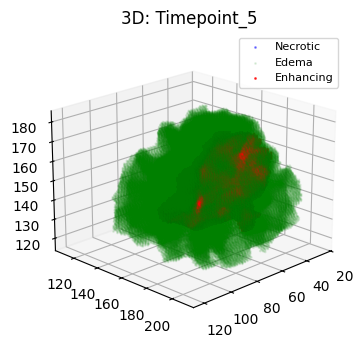

   KINETIC VELOCITY (Change per Day) over 140.0 days:
      Label        |       ΔVol |        ΔT1c(μ|σ) |        ΔT1n(μ|σ) |        ΔT2f(μ|σ) |        ΔT2w(μ|σ)
      -------------+------------+------------------+------------------+------------------+-----------------
      Necrotic     |      32.17 |    0.77|   0.00  |    1.18|   0.14  |   -1.51|  -0.53  |    2.21|   0.04 
      Edema        |     720.54 |    1.04|   0.06  |    1.29|   0.06  |   -0.48|   0.05  |    2.81|   0.48 
      Enhancing    |      13.55 |    0.40|  -0.14  |    0.71|  -0.20  |   -1.40|  -0.30  |    2.28|  -0.06 

 PatientID_0004 - 3D TUMOR ARCHITECTURE & RATE ANALYSIS 

 Timepoint_1 | Day 67.0
   📊 COMPARTMENTAL ANALYSIS (Radiomics):
      Label        |  Vol (mm³) |  Vox Count |      T1c (μ±σ) |      T1n (μ±σ) |      T2f (μ±σ) |      T2w (μ±σ)
      -------------+------------+------------+----------------+----------------+----------------+---------------
      Necrotic     |     2174.0 |       2174 |  344.0(±3

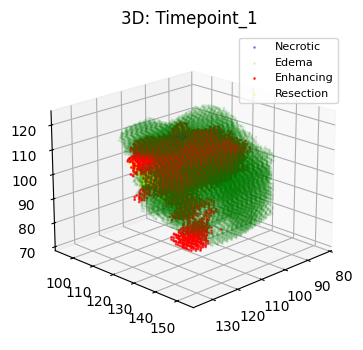

   Baseline established. Kinetics will be calculated at next timepoint.

 PatientID_0005 - 3D TUMOR ARCHITECTURE & RATE ANALYSIS 

 Timepoint_3 | Day 133.0
   📊 COMPARTMENTAL ANALYSIS (Radiomics):
      Label        |  Vol (mm³) |  Vox Count |      T1c (μ±σ) |      T1n (μ±σ) |      T2f (μ±σ) |      T2w (μ±σ)
      -------------+------------+------------+----------------+----------------+----------------+---------------
      Necrotic     |     2946.0 |       2946 |  405.8(±34.7)  |  207.7(±43.0)  |  478.5(±53.8)  |  750.0(±87.8) 
      Edema        |    93727.0 |      93727 |  396.4(±22.8)  |  260.5(±86.9)  |  500.3(±73.2)  |  542.5(±99.1) 
      Enhancing    |    42780.0 |      42780 |  543.5(±104.1) |  233.1(±68.3)  |  501.4(±75.9)  |  627.9(±119.7)
      Resection    |        --- |        --- |            --- |            --- |            --- |            ---

   🔍 IMAGE VALIDATION (Pixels vs CSV):
      Necrotic     | Pixels:     2946 | Calc_Vol:     2946.0 | CSV_Vol:     2946.0
  

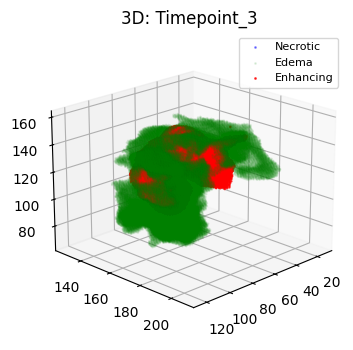

   Baseline established. Kinetics will be calculated at next timepoint.

 Timepoint_4 | Day 176.0
   📊 COMPARTMENTAL ANALYSIS (Radiomics):
      Label        |  Vol (mm³) |  Vox Count |      T1c (μ±σ) |      T1n (μ±σ) |      T2f (μ±σ) |      T2w (μ±σ)
      -------------+------------+------------+----------------+----------------+----------------+---------------
      Necrotic     |    10541.0 |      10541 |  240.8(±54.8)  |  211.1(±45.0)  |  493.9(±73.5)  |  797.8(±100.4)
      Edema        |   102189.0 |     102189 |  306.0(±35.4)  |  295.7(±36.8)  |  507.4(±57.5)  |  553.2(±102.0)
      Enhancing    |    27581.0 |      27581 |  445.1(±122.9) |  235.4(±37.5)  |  501.3(±79.1)  |  696.2(±122.4)
      Resection    |        --- |        --- |            --- |            --- |            --- |            ---

   🔍 IMAGE VALIDATION (Pixels vs CSV):
      Necrotic     | Pixels:    10541 | Calc_Vol:    10541.0 | CSV_Vol:    10541.0
      Edema        | Pixels:   102189 | Calc_Vol:   102189.0

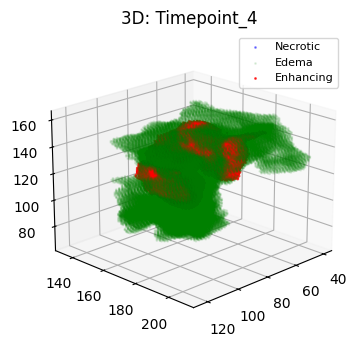

   KINETIC VELOCITY (Change per Day) over 43.0 days:
      Label        |       ΔVol |        ΔT1c(μ|σ) |        ΔT1n(μ|σ) |        ΔT2f(μ|σ) |        ΔT2w(μ|σ)
      -------------+------------+------------------+------------------+------------------+-----------------
      Necrotic     |     176.63 |   -3.84|   0.47  |    0.08|   0.05  |    0.36|   0.46  |    1.11|   0.29 
      Edema        |     196.79 |   -2.10|   0.29  |    0.82|  -1.16  |    0.16|  -0.37  |    0.25|   0.07 
      Enhancing    |    -353.47 |   -2.29|   0.44  |    0.05|  -0.72  |   -0.00|   0.07  |    1.59|   0.06 

 PatientID_0006 - 3D TUMOR ARCHITECTURE & RATE ANALYSIS 

 Timepoint_2 | Day 175.0
   📊 COMPARTMENTAL ANALYSIS (Radiomics):
      Label        |  Vol (mm³) |  Vox Count |      T1c (μ±σ) |      T1n (μ±σ) |      T2f (μ±σ) |      T2w (μ±σ)
      -------------+------------+------------+----------------+----------------+----------------+---------------
      Necrotic     |      289.0 |        289 |  657.1(±6

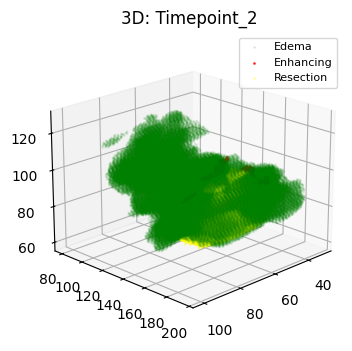

   Baseline established. Kinetics will be calculated at next timepoint.

 Timepoint_4 | Day 217.0
   📊 COMPARTMENTAL ANALYSIS (Radiomics):
      Label        |  Vol (mm³) |  Vox Count |      T1c (μ±σ) |      T1n (μ±σ) |      T2f (μ±σ) |      T2w (μ±σ)
      -------------+------------+------------+----------------+----------------+----------------+---------------
      Necrotic     |        --- |        --- |            --- |            --- |            --- |            ---
      Edema        |    55705.0 |      55705 |  671.4(±68.0)  |  667.2(±81.1)  |  503.2(±66.4)  |  549.3(±130.4)
      Enhancing    |      962.0 |        962 |  850.0(±122.6) |  681.0(±122.9) |  443.0(±99.5)  |  572.8(±156.6)
      Resection    |    26382.0 |      26382 |  392.4(±164.6) |  549.8(±248.9) |  240.0(±162.3) |  928.7(±236.3)

   🔍 IMAGE VALIDATION (Pixels vs CSV):
      Edema        | Pixels:    55705 | Calc_Vol:    55705.0 | CSV_Vol:    55705.0
      Enhancing    | Pixels:      962 | Calc_Vol:      962.0

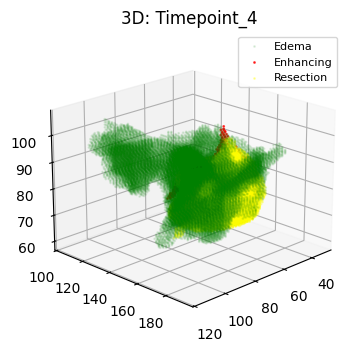

   KINETIC VELOCITY (Change per Day) over 42.0 days:
      Label        |       ΔVol |        ΔT1c(μ|σ) |        ΔT1n(μ|σ) |        ΔT2f(μ|σ) |        ΔT2w(μ|σ)
      -------------+------------+------------------+------------------+------------------+-----------------
      Necrotic     |      -6.88 |  -15.64|  -1.51  |  -14.05|  -1.20  |  -11.75|  -1.64  |  -28.85|  -3.88 
      Edema        |   -1783.64 |    4.55|   0.38  |    4.89|   0.74  |    0.17|   0.19  |   -0.75|   0.35 
      Enhancing    |     -38.86 |    4.55|  -0.14  |    1.04|  -0.36  |   -2.27|  -0.20  |   -2.04|  -0.01 
      Resection    |    -147.07 |    0.34|   2.10  |    4.09|   4.12  |   -6.26|   1.39  |   -3.50|   0.22 

 Timepoint_5 | Day 259.0
   📊 COMPARTMENTAL ANALYSIS (Radiomics):
      Label        |  Vol (mm³) |  Vox Count |      T1c (μ±σ) |      T1n (μ±σ) |      T2f (μ±σ) |      T2w (μ±σ)
      -------------+------------+------------+----------------+----------------+----------------+---------------
      

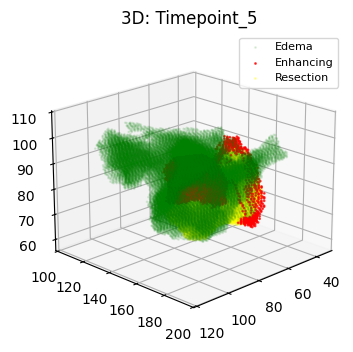

   KINETIC VELOCITY (Change per Day) over 42.0 days:
      Label        |       ΔVol |        ΔT1c(μ|σ) |        ΔT1n(μ|σ) |        ΔT2f(μ|σ) |        ΔT2w(μ|σ)
      -------------+------------+------------------+------------------+------------------+-----------------
      Edema        |     160.98 |   -0.32|  -0.46  |   -9.54|  -1.43  |   -2.59|  -0.41  |   -3.43|  -1.29 
      Enhancing    |     158.86 |   -1.52|  -0.60  |   -9.61|  -1.59  |   -0.34|  -0.42  |   -2.44|  -1.80 
      Resection    |      28.83 |    0.40|  -0.18  |   -8.57|  -3.92  |   -0.44|  -0.32  |   -5.46|  -2.41 

 Timepoint_6 | Day 450.0
   📊 COMPARTMENTAL ANALYSIS (Radiomics):
      Label        |  Vol (mm³) |  Vox Count |      T1c (μ±σ) |      T1n (μ±σ) |      T2f (μ±σ) |      T2w (μ±σ)
      -------------+------------+------------+----------------+----------------+----------------+---------------
      Necrotic     |        --- |        --- |            --- |            --- |            --- |            ---
 

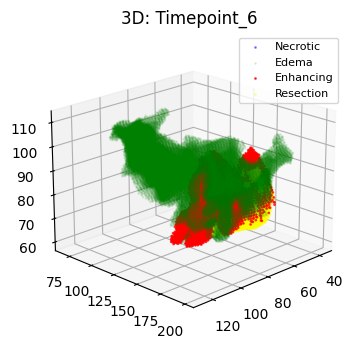

   KINETIC VELOCITY (Change per Day) over 191.0 days:
      Label        |       ΔVol |        ΔT1c(μ|σ) |        ΔT1n(μ|σ) |        ΔT2f(μ|σ) |        ΔT2w(μ|σ)
      -------------+------------+------------------+------------------+------------------+-----------------
      Edema        |      79.93 |   -0.07|  -0.09  |    1.93|   0.03  |    0.63|   0.03  |    0.87|   0.17 
      Enhancing    |      58.39 |    0.60|   0.30  |    2.02|   0.02  |    0.35|   0.10  |    1.10|   0.64 
      Resection    |     -26.97 |    0.06|  -0.34  |    1.07|   0.03  |   -0.60|  -0.11  |    2.85|   0.75 

 PatientID_0007 - 3D TUMOR ARCHITECTURE & RATE ANALYSIS 

 Timepoint_2 | Day 0.0
   📊 COMPARTMENTAL ANALYSIS (Radiomics):
      Label        |  Vol (mm³) |  Vox Count |      T1c (μ±σ) |      T1n (μ±σ) |      T2f (μ±σ) |      T2w (μ±σ)
      -------------+------------+------------+----------------+----------------+----------------+---------------
      Necrotic     |        --- |        --- |           

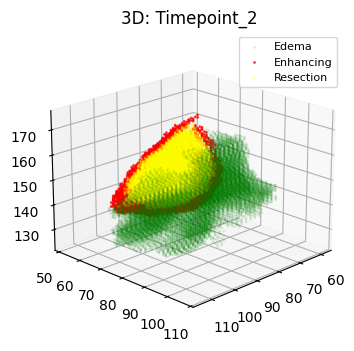

   Baseline established. Kinetics will be calculated at next timepoint.

 Timepoint_3 | Day nan
   📊 COMPARTMENTAL ANALYSIS (Radiomics):
      Label        |  Vol (mm³) |  Vox Count |      T1c (μ±σ) |      T1n (μ±σ) |      T2f (μ±σ) |      T2w (μ±σ)
      -------------+------------+------------+----------------+----------------+----------------+---------------
      Necrotic     |        --- |        --- |            --- |            --- |            --- |            ---
      Edema        |    33179.0 |      33179 |  574.7(±42.3)  |  672.9(±46.5)  |  557.1(±71.3)  |  690.0(±150.2)
      Enhancing    |     5996.0 |       5996 |  701.0(±125.8) |  618.3(±60.8)  |  402.7(±88.7)  |  866.1(±253.0)
      Resection    |     8934.0 |       8934 |  450.1(±58.7)  |  514.0(±40.1)  |  257.5(±30.9)  | 1265.3(±182.9)

   🔍 IMAGE VALIDATION (Pixels vs CSV):
      Edema        | Pixels:    33179 | Calc_Vol:    33179.0 | CSV_Vol:    33179.0
      Enhancing    | Pixels:     5996 | Calc_Vol:     5996.0 |

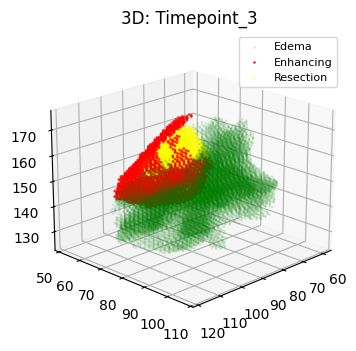

   Baseline established. Kinetics will be calculated at next timepoint.

 Timepoint_4 | Day 178.0
   📊 COMPARTMENTAL ANALYSIS (Radiomics):
      Label        |  Vol (mm³) |  Vox Count |      T1c (μ±σ) |      T1n (μ±σ) |      T2f (μ±σ) |      T2w (μ±σ)
      -------------+------------+------------+----------------+----------------+----------------+---------------
      Necrotic     |        --- |        --- |            --- |            --- |            --- |            ---
      Edema        |    54831.0 |      54831 |  555.9(±53.2)  |  207.6(±29.5)  |  368.2(±48.5)  |  467.1(±93.7) 
      Enhancing    |     3263.0 |       3263 |  616.0(±108.7) |  166.6(±32.3)  |  243.0(±76.9)  |  519.9(±102.7)
      Resection    |     5832.0 |       5832 |  395.8(±63.5)  |  123.6(±23.2)  |  120.8(±53.0)  |  648.1(±79.3) 

   🔍 IMAGE VALIDATION (Pixels vs CSV):
      Edema        | Pixels:    54831 | Calc_Vol:    54831.0 | CSV_Vol:    54831.0
      Enhancing    | Pixels:     3263 | Calc_Vol:     3263.0

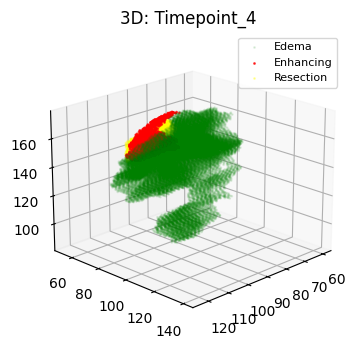

   Baseline established. Kinetics will be calculated at next timepoint.

 Timepoint_5 | Day 264.0
   📊 COMPARTMENTAL ANALYSIS (Radiomics):
      Label        |  Vol (mm³) |  Vox Count |      T1c (μ±σ) |      T1n (μ±σ) |      T2f (μ±σ) |      T2w (μ±σ)
      -------------+------------+------------+----------------+----------------+----------------+---------------
      Necrotic     |        --- |        --- |            --- |            --- |            --- |            ---
      Edema        |    59179.0 |      59179 |  576.8(±58.6)  |  225.8(±31.1)  |  388.7(±50.6)  |  507.5(±106.4)
      Enhancing    |     4074.0 |       4074 |  674.7(±142.5) |  175.8(±35.3)  |  253.6(±77.7)  |  606.4(±127.9)
      Resection    |     3742.0 |       3742 |  447.0(±62.5)  |  143.8(±23.9)  |  155.4(±39.7)  |  739.4(±90.6) 

   🔍 IMAGE VALIDATION (Pixels vs CSV):
      Edema        | Pixels:    59179 | Calc_Vol:    59179.0 | CSV_Vol:    59179.0
      Enhancing    | Pixels:     4074 | Calc_Vol:     4074.0

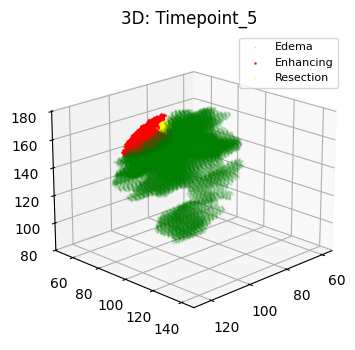

   KINETIC VELOCITY (Change per Day) over 86.0 days:
      Label        |       ΔVol |        ΔT1c(μ|σ) |        ΔT1n(μ|σ) |        ΔT2f(μ|σ) |        ΔT2w(μ|σ)
      -------------+------------+------------------+------------------+------------------+-----------------
      Edema        |      50.56 |    0.24|   0.06  |    0.21|   0.02  |    0.24|   0.02  |    0.47|   0.15 
      Enhancing    |       9.43 |    0.68|   0.39  |    0.11|   0.04  |    0.12|   0.01  |    1.01|   0.29 
      Resection    |     -24.30 |    0.60|  -0.01  |    0.23|   0.01  |    0.40|  -0.15  |    1.06|   0.13 

 Timepoint_6 | Day 366.0
   📊 COMPARTMENTAL ANALYSIS (Radiomics):
      Label        |  Vol (mm³) |  Vox Count |      T1c (μ±σ) |      T1n (μ±σ) |      T2f (μ±σ) |      T2w (μ±σ)
      -------------+------------+------------+----------------+----------------+----------------+---------------
      Necrotic     |        --- |        --- |            --- |            --- |            --- |            ---
 

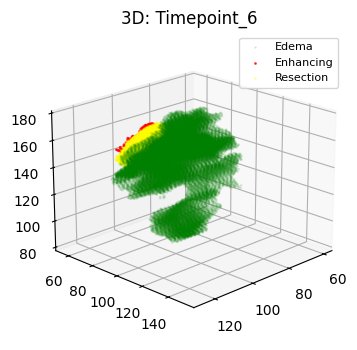

   KINETIC VELOCITY (Change per Day) over 102.0 days:
      Label        |       ΔVol |        ΔT1c(μ|σ) |        ΔT1n(μ|σ) |        ΔT2f(μ|σ) |        ΔT2w(μ|σ)
      -------------+------------+------------------+------------------+------------------+-----------------
      Edema        |      20.12 |   -2.77|  -0.25  |    0.55|  -0.01  |   -0.58|  -0.12  |   -0.37|   0.10 
      Enhancing    |     -33.66 |   -2.27|  -0.67  |    0.74|  -0.01  |   -0.21|  -0.23  |   -0.68|  -0.02 
      Resection    |      23.82 |   -2.09|  -0.19  |    0.63|   0.01  |    0.04|   0.03  |    0.19|   0.35 




In [10]:
# COMBINED 3D VISUALIZATION + RATE ANALYSIS with Segmentation data

segmentation_labels = {1: "Necrotic", 2: "Edema", 3: "Enhancing", 4: "Resection"}
sequences = ['t1c', 't1n', 't2f', 't2w']
colors = ["blue", "green", "red", "yellow"]

for VHT_Id in list(patient_objects.keys())[:5]:
    print(f"\n{'='*130}\n {VHT_Id} - 3D TUMOR ARCHITECTURE & RATE ANALYSIS \n{'='*130}")
    
    if VHT_Id in patient_objects:
        patient = patient_objects[VHT_Id]
        clinical = patient.get('clinical', {})
        sorted_timepoints = sorted(patient['timepoints'])
        history = None 

        for tp_idx, tp in enumerate(sorted_timepoints):
            # 1. Identify Day Offset
            tp_num = "".join(filter(str.isdigit, tp))
            days_str = next((v for k, v in clinical.items() if f"Timepoint_{tp_num}" in k), "0")
            
            try:
                curr_day = float(days_str)
            except:
                curr_day = np.nan
            
            print(f"\n {tp} | Day {curr_day}")

            # 2. Handle Images & Mask
            image_list = sorted(patient['images'].get(tp, []))
            mask_path = next((p for p in image_list if "mask" in Path(p).name.lower()), None)
            if not mask_path and len(image_list) > 4: mask_path = image_list[4]

            # --- A. COMPARTMENTAL ANALYSIS (CSV Data with Mean ± Stdev) ---
            print(f"   📊 COMPARTMENTAL ANALYSIS (Radiomics):")
            # Adjusted header for clarity
            print(f"      {'Label':12} | {'Vol (mm³)':>10} | {'Vox Count':>10} | {'T1c (μ±σ)':>14} | {'T1n (μ±σ)':>14} | {'T2f (μ±σ)':>14} | {'T2w (μ±σ)':>14}")
            print(f"      {'-'*12}-+-{'-'*10}-+-{'-'*10}-+-{'-'*14}-+-{'-'*14}-+-{'-'*14}-+-{'-'*14}")
            
            for l_val, l_name in segmentation_labels.items():
                vol = patient['volumes'].get(tp, {}).get(l_name, 0)
                vox = patient['voxels'].get(tp, {}).get(l_name, 0)

                # Extraction of Means and Stdevs
                m_t1c = patient['t1c_mean'].get(tp, {}).get(l_name, 0)
                std_t1c = patient['t1c_stdevs'].get(tp, {}).get(l_name, 0)

                m_t1n = patient['t1n_mean'].get(tp, {}).get(l_name, 0)
                std_t1n = patient['t1n_stdevs'].get(tp, {}).get(l_name, 0)

                m_t2f = patient['t2f_mean'].get(tp, {}).get(l_name, 0)
                std_t2f = patient['t2f_stdevs'].get(tp, {}).get(l_name, 0)

                m_t2w = patient['t2w_mean'].get(tp, {}).get(l_name, 0)
                std_t2w = patient['t2w_stdevs'].get(tp, {}).get(l_name, 0)
                
                if vol > 0:
                    # Formatting strings as "Mean(±Std)" for a compact, readable view
                    t1c_str = f"{m_t1c:>6.1f}(±{std_t1c:>4.1f})"
                    t1n_str = f"{m_t1n:>6.1f}(±{std_t1n:>4.1f})"
                    t2f_str = f"{m_t2f:>6.1f}(±{std_t2f:>4.1f})"
                    t2w_str = f"{m_t2w:>6.1f}(±{std_t2w:>4.1f})"

                    print(f"      {l_name:12} | {vol:>10.1f} | {vox:>10.0f} | {t1c_str:14} | {t1n_str:14} | {t2f_str:14} | {t2w_str:14}")
                else:
                    # Empty row filler
                    print(f"      {l_name:12} | {'---':>10} | {'---':>10} | {'---':>14} | {'---':>14} | {'---':>14} | {'---':>14}")

            # --- B. VOLUME VALIDATION & 3D (If Mask Exists) ---
            if mask_path:
                img_obj = nib.load(mask_path)
                mask_data = img_obj.get_fdata()
                vox_vol = np.prod(img_obj.header.get_zooms()[:3])
                u_lvls, counts = np.unique(mask_data, return_counts=True)
                pixel_count_dict = dict(zip(u_lvls.astype(int), counts))

                print(f"\n   🔍 IMAGE VALIDATION (Pixels vs CSV):")
                for l_val, l_name in segmentation_labels.items():
                    p_count = pixel_count_dict.get(l_val, 0)
                    calc_vol = p_count * vox_vol
                    csv_vol = patient['volumes'].get(tp, {}).get(l_name, 0)
                    
                    if p_count > 0 or csv_vol > 0:
                        print(f"      {l_name:12} | Pixels: {p_count:8d} | Calc_Vol: {calc_vol:10.1f} | CSV_Vol: {csv_vol:10.1f}")

                # 3D Visualization
                fig = plt.figure(figsize=(5, 4))
                ax = fig.add_subplot(111, projection='3d')
                transparency = {1: 0.4, 2: 0.1, 3: 0.7, 4: 0.3}
                for idx, (level, name) in enumerate(segmentation_labels.items()):
                    level_mask = (mask_data == level)
                    if np.any(level_mask):
                        z, y, x = np.where(level_mask)
                        ax.scatter(x[::2], y[::2], z[::2], c=colors[idx], label=name, alpha=transparency.get(level, 0.3), s=1)
                ax.set_title(f"3D: {tp}")
                ax.legend(fontsize=8); ax.view_init(20, 45)
                plt.show()

            # --- C. KINETIC RATE CALCULATION (Mean & Stdev Velocity) ---
            current_tp_data = {}
            for l_val, l_name in segmentation_labels.items():
                current_tp_data[l_name] = {
                    'vol': patient['volumes'].get(tp, {}).get(l_name, 0),
                    'stats': {
                        seq: {
                            'm': patient[f'{seq}_mean'].get(tp, {}).get(l_name, 0),
                            's': patient[f'{seq}_stdevs'].get(tp, {}).get(l_name, 0)
                        } for seq in sequences
                    }
                }

            if history is not None and not np.isnan(curr_day) and not np.isnan(history['day']):
                dt = curr_day - history['day']
                if dt > 0:
                    print(f"   KINETIC VELOCITY (Change per Day) over {dt:.1f} days:")
                    # Header showing Mean(μ) and Stdev(σ) rates
                    print(f"      {'Label':12} | {'ΔVol':>10} | {'ΔT1c(μ|σ)':>16} | {'ΔT1n(μ|σ)':>16} | {'ΔT2f(μ|σ)':>16} | {'ΔT2w(μ|σ)':>16}")
                    print(f"      {'-'*12}-+-{'-'*10}-+-{'-'*16}-+-{'-'*16}-+-{'-'*16}-+-{'-'*16}")
                    
                    for l_name in segmentation_labels.values():
                        curr = current_tp_data[l_name]
                        prev = history['data'][l_name]
                        
                        if curr['vol'] > 0 or prev['vol'] > 0:
                            # 1. Volume Velocity
                            dv = (curr['vol'] - prev['vol']) / dt
                            
                            # 2. Sequence Kinetics (Mean and Stdev change)
                            # Result string format: "MeanRate | StdRate"
                            rates = {}
                            for seq in sequences:
                                dm = (curr['stats'][seq]['m'] - prev['stats'][seq]['m']) / dt
                                ds = (curr['stats'][seq]['s'] - prev['stats'][seq]['s']) / dt
                                rates[seq] = f"{dm:>7.2f}|{ds:>7.2f}"

                            print(f"      {l_name:12} | {dv:>10.2f} | {rates['t1c']:16} | {rates['t1n']:16} | {rates['t2f']:16} | {rates['t2w']:16}")
                else:
                    print("   Rates unavailable: Scans performed on same day or invalid order.")
            else:
                print("   Baseline established. Kinetics will be calculated at next timepoint.")

            # Update history for the next iteration
            history = {'day': curr_day, 'data': current_tp_data}
print(f"\n{'='*130}\n")

In [39]:

demographics = [('Age', 'Age at diagnosis'), 
                ('Sex', 'Sex at Birth'), 
                ('Race', 'Race')]
molecular = [
    ('MGMT methylation', 'MGMT methylation'), # 0 - No MGMT methylation, 1 - MGMT promoter methylation, 2 - Indeterminate MGMT promoter methylation status, 3 - Unable to assess MGMT promoter methyltion status, 4 - Unknown
    ('IDH1 mutation', 'IDH1 mutation'), # 0 - No IDH1 mutation, 1 - IDH1 mutation is present, 2 - Unknown
    ('IDH2 mutation', 'IDH2 mutation'), # 0 - No IDH2 mutation, 1 - IDH2 mutation is present, 2 - Unknown
    ('1p19q', '1p/19q'), # 0 - No Co-deletion, 1 - Co-deletion, 2 - 19q deletion, 3 - 19q duplication or trisomy, 4 - 19q duplication, 5 - Gain of 19, 6 - 1p deletion, 7 - Tetraploid, 8 - 19q trisomy, 9 - Abnormal karyotype, 10 - Unknown
    ('ATRX mutation', 'ATRX mutation'), # 0 - No ATRX mutation, 1 - ATRX mutation is present, 2 - ATRX is mosaic, 3 - Possible mosaicism, 4 - Unknown
    ('BRAF V600E mutation', 'BRAF V600E mutation'), # 0 - No BRAF V600E mutation, 1 - BRAF V600E mutation is present, 2 - BRAF V600E mutation is unknown
    ('EGFR amplification', 'EGFR amplification'), # 0 - No EGFR amplification, 1 - EGFR amplification, 2 - EGFR amplification is unknown
    ('TERT promoter mutation', 'TERT promoter mutation'), #0 - No TERT promoter mutation, 1 - TERT promoter mutation is present, 2 - TERT promoter mutation is unknown
    ('Chromosome 7 gain and Chromosome 10 loss', 'Chromosome 7 gain and Chromosome 10 loss'), # 0 - No Chromosome 7 gain and Chromosome 10 loss, 1 - Chromosome 7 gain and Chromosome 10 loss, 2 - Chromosome 7 gain and Chromosome 10 loss is unknown
    ('H3-3A mutation', 'H3-3A mutation'), # 0 - No H3-3A mutation, 1 - H3-3A mutation is present, 2 - H3-3A mutation is unknown
    ('PTEN mutation', 'PTEN mutation'), # 0 - No PTEN mutation, 1 - PTEN mutation is present
    ('CDKN2A/B deletion', 'CDKN2A/B deletion'), # 0 - No CDKN2A/B deletion, 1 - CDKN2A/B deletion is present, 2 - CDKN2A/B deletion is unknown
    ('TP53 alteration', 'TP53 alteration'), # 0 - No TP53 alteration, 1 - TP53 alteration is present
    ('Other mutations/alterations', 'Other mutations/alterations') # c-myc reactive/ Gain of 4q11q12, amplification of 12q15q21.1, loss of 13q12.2q14.2, gain of 21, loss of 225. loss of 17/ MSH6, CIC, FAF1/ RB1/ PRDM2, CDK6, MET/ RB1, LRP1B/ Loss of 9p21.3/ LZRT1,  NF1/ NF1, PIK3CA, loss of 9P21.3/ PIK3CA, PTPN11/ RB1, LZTR1, loss of chromosome 13/ RPL5, APC, DDX3X/ APC/ FGFR1/ SEDT2/ PTCH1, RB1, NF1/ NTRK2, RB1/ NF1/ EGFR-SEPT14 fusion/ PIK3R1/ RB1, gain of chromosome 19/ MDM4/ PIK3R1, TSC1, variant of APC/ NF1, PTPN11/ PIK3CA, NRAS/ MTOR, copy number complexity, PDGFRA amplification/ RB1, ARID1A/ H3.3 K27M/ H3 K27M/ KMT2D, complex microarray/ Amplification of MYCN, CDK4/ NF2/ Amplification of PDGFRA and CDK4/ CDK4, NF1/ Likely tetraploid tumor/ MYB, PLAGL1/ MYC/ CTNNB1, EED, CDKN2A/B, PDGFRA/MET/ DICER1, PMS2/ H3K27M/ FGFR2/ FGFR1, PTPN11, gains of chromosomes 6,7,10,11,12,13,18/ PTPN11/ PDGFRA/ PIK3CA, BCOR, SETD2
]
diagnosis = [
    ('Primary Diagnosis', 'Primary Diagnosis'), #Pilocytic astrocytoma, Astrocytoma, Oligodendro-glioma, Neurocytoma, Glioneural, Diffuse glioma, Glioma w/ GBM features, GBM
    ('Grade of Primary Brain Tumor', 'Grade of Primary Brain Tumor'), #Grade 1, Grade 2, Grade 3, Grade 4
    ('Surg_Days', 'Number of days from Diagnosis to First surgery or procedure '), # 
    ('Biopsy', 'Stereotactic Biopsy before Surgical Resection'), # 0 - No stereotactic biopsy before surgery, 1- Stereotactic biopsy done before surgical resection of the tumor
    ('Multiple_Surg', 'Multiple surgeries'), # 0 - No second look or other brain surgeries, 1 - Patient underwent a second look or multiple brain surgeries,
    ('Previous Brain Tumor', 'Previous Brain Tumor'), # Yes, No
    ('Type of previous brain tumor', 'Type of previous brain tumor'), # Indicate the Previous Brain Tumor Type if the patient has
    ('Year of previous surgery', 'Year of previous surgery'), # Indicate the Year when the Previous Brain Tumor has been resected
    ('Grade of Previous brain tumor', 'Grade of Previous brain tumor'), # Grade 2, Grade 3, Grade 4
    ('Hospice', 'Hospice'), # 0: Patient did not receive hospice care, 1: Patient received hospice care
    ('Number of days from Diagnosis to date of First Progression', 'Number of days from Diagnosis to date of First Progression'), # Indicate the # of days from the Time of Diagnosis to the Documented Day of First Progression
    ('Number of days from Diagnosis to date of Further Progression', 'Number of days from Diagnosis to date of Further Progression'), # Indicate the # of days from the Time of Diagnosis to the Documented Day of Further Progression
    ('Treatment started after 2nd progression', 'Treatment started after 2nd progression'), # Indicate if any Type of Treatment after the Documented Day of second Progression
    ('Days from Diagnosis to new treatment after 2nd progression', 'Days from Diagnosis to new treatment after 2nd progression'), # Indicate the # of days from the Time of Diagnosis to the Start Date of New Treatment
    ('Additional Therapy', 'Additional Therapy'), # Indicated if there is any Additional Therapy
    ('Cycle length of Additional Therapy (q days)', 'Cycle length of Additional Therapy (q days)'), # Indicate the # of days for each cycle of Additional Therapy (if any) 
    ('Number of Days from Diagnosis to Starting Additional Therapy', 'Number of Days from Diagnosis to Starting Additional Therapy'), # Indicate the # of days from the Time of Diagnosis to Start the Additional Therapy (if any)
    ('Number of Days from Diagnosis to Complete Additional Therapy', 'Number of Days from Diagnosis to Complete Additional Therapy'), # Indicate the # of days from the Time of Diagnosis to Complete the Additional Therapy (if any)
    ('Number of Cycles of Additional Therapy', 'Number of Cycles of Additional Therapy'), # Indicated the # of Treatment Cycles of the Additional Therapy if multiple
    ('2nd_Additional Therapy', '2nd Additional Therapy'), # Indicated if there is any further Additional Therapy
    ('Cycle length of 2nd_Additional Therapy (q days)', 'Cycle length of 2nd_Additional Therapy (q days)'), # Indicate the # of days for each cycle of the 2nd_Additional Therapy (if any) 
    ('Number of Days from Diagnosis to Starting 2nd_Additional Therapy', 'Number of Days from Diagnosis to Starting 2nd_Additional Therapy'), # Indicate the # of days from the Time of Diagnosis to Start the 2nd_Additional Therapy (if any)
    ('Number of Days from Dagnosis to Complete 2nd_Additional Therapy', 'Number of Days from Dagnosis to Complete 2nd_Additional Therapy'), # Indicate the # of days from the Time of Diagnosis to Complete the 2nd_Additional Therapy (if any)
    ('Number of Cycles of 2nd_Additional Therapy', 'Number of Cycles of 2nd_Additional Therapy'), # Indicated the # of Treatment Cycles of the Additional Therapy if multiple
    ('Immuno therapy', 'Immuno therapy'), # Indicated if the Patient received Immunotherapy (Name of Immunotherapeutic agent) or Not
    ('Cycle length of Immunotherapy (q days)', 'Cycle length of Immunotherapy (q days)'), # Indicate the # of days for each cycle of the Immunotherapy (if any)
    ('Number of Days from Diagnosis to Start Immunotherapy', 'Number of Days from Diagnosis to Start Immunotherapy'), # Indicate the # of days from the Time of Diagnosis to Start the Immunotherapy (if any)
    ('Number of Days from Diagnosis to Complete Immunotherapy', 'Number of Days from Diagnosis to Complete Immunotherapy'), # Indicate the # of days from the Time of Diagnosis to Complete the Immunotherapy (if any)
    ('Number of Cycles of Immunotherapy', 'Number of Cycles of Immunotherapy'), # Indicated the # of Treatment Cycles of the Immunotherapy if multiple
    ('Brachy therapy', 'Brachy therapy'), # Indicated if the Patient received Braachy therapy or Not
    ('Number of Days from Diagnosis to the day of Insertion of Brachytherapy', 'Number of Days from Diagnosis to the day of Insertion of Brachytherapy'), # Indicate the # of days from the Time of Diagnosis to the Documented day of Insertion of the Brachy therapy (if any)
    ('Other Type of Therapy (LITT, more chemo, proton therapy)', 'Other Type of Therapy (LITT, more chemo, proton therapy)'), # Indicated if there is any further Additional Therapy (Type of Treatment e.g. LITT, more chemo, proton therapy) or Not
    ('Number of Days from Diagnosis to Start Other Additional Therapy', 'Number of Days from Diagnosis to Start Other Additional Therapy'), # Indicate the # of days from the Time of Diagnosis to Start any further Additional Therapy (if any)
    ('Number of Days from Diagnosis to Complete Other Additional Therapy', 'Number of Days from Diagnosis to Complete Other Additional Therapy') # Indicate the # of days from the Time of Diagnosis to Complete any further Additional Therapy (if any)
]
    
progression_survival = [
    ('Progression', 'Progression'),# 1: Yes, 0: No
    ('Type of Progression', 'Type of Progression'), # 0: No Progression, 1: Progression by Imaging criteria, 2: Progression by clinical criteria, 3: Progression by both imaging and clinical criteria,
    ('Days_to_Prog', 'Time to First Progression (Days)'), # Time from diagnosis or surgical resection of the tumor to the occurrence of progression in days
    ('Type of 2nd Progression', 'Type of 2nd Progression'), # 0: No Progression, 1: Progression by Imaging criteria, 2: Progression by clinical criteria, 3: Progression by both imaging and clinical criteria
    ('Overall_Survival', 'Overall Survival (Death)'), # 1: Documented patient death in EMR, 0: 0 - No death recorded (Patient alive, lost follow-up or unknown death status)
    ('Days_to_Death', 'Number of days from Diagnosis to death (Days)'), # Number of days from Diagnosis to Death (Days)
    
]

treatment = [
    ('Initial Chemo Therapy', 'Initial Chemo Therapy'), # Yes, NA
    ('Name of initial Chemotherapy', 'Name of initial Chemotherapy'), # The Name of Chemotherapeutic agent
    ('Number of days from Diagnosis to Initial Chemo Therapy Start date', 'Number of days from Diagnosis to Initial Chemo Therapy Start date'), # Indicate the # of days from the Time of Diagnosis to the Initial Chemotherapy
    ('Number of days from Diagnosis to Initial Chemo Therapy end date', 'Number of days from Diagnosis to Initial Chemo Therapy end date'), # Indicate the # of days from the Time of Diagnosis to Complete the Initial Chemotherapy 
    ('Radiation Therapy', 'Radiation Therapy'), # Yes, NA
    ('Number of days from Diagnosis to Radiation Therapy Start date', 'Number of days from Diagnosis to Radiation Therapy Start date'), # Indicate the # of days from the Time of Diagnosis to the Start Date of Radiation Therapy
    ('Number of days from Diagnosis to Radiation Therapy end date', 'Number of days from Diagnosis to Radiation Therapy end date'), # Indicate the # of days from the Time of Diagnosis to the Completion Date of Radiation Therapy
    ('Dose of Radiation Therapy', 'Dose'), # Total Radiation Dose in Gy
    ('Rad_Fractions', 'Number of Fractions') # Indicate the # of fractions of Radiation Therapy

]
temporal_mri = [
    ('MRI_TP1', 'Number of Days from Diagnosis to 1st MRI (Timepoint_1)'),
    ('MRI_TP2', 'Number of Days from Diagnosis to 2nd MRI (Timepoint_2)'),
    ('MRI_TP3', 'Number of Days from Diagnosis to 3rd MRI (Timepoint_3)'),
    ('MRI_TP4', 'Number of Days from Diagnosis to 4th MRI (Timepoint_4)'),
    ('MRI_TP5', 'Number of Days from Diagnosis to 5th MRI (Timepoint_5)'),
    ('MRI_TP6', 'Number of Days from Diagnosis to 6th MRI (Timepoint_6)'),
]

In [55]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.metrics import classification_report, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder

# 1. Read CSV file
clinical_data_path = "/Users/kasunachinthaperera/Documents/Final Year Project:Thesis/Data/PKG - MU-Glioma-Post/MU-Glioma-Post_ClinicalData-July2025.xlsx"
clinical_data = pd.ExcelFile(clinical_data_path)
df = pd.read_excel(clinical_data_path, sheet_name='MU Glioma Post')
df.columns = df.columns.str.strip()

# 2. Updated Feature List (Matching exact stripped names and typos in your CSV)
features = [
    # --- Demographics ---
    'Age at diagnosis', 'Sex at Birth', 'Race',
    
    # --- Molecular Markers ---
    'MGMT methylation', 'IDH1 mutation', 'IDH2 mutation', '1p/19q', 
    'ATRX mutation', 'BRAF V600E mutation', 'EGFR amplification', 
    'TERT promoter mutation', 'Chromosome 7 gain and Chromosome 10 loss', 
    'H3-3A mutation', 'PTEN mutation', 'CDKN2A/B deletion', 'TP53 alteration',
    
    
    # --- Diagnosis & History ---
    'Primary Diagnosis', 'Grade of Primary Brain Tumor', 
    'Number of days from Diagnosis to First surgery or procedure', # Removed trailing space
    'Stereotactic Biopsy before Surgical Resection', 'Multiple surgeries', 
    'Previous Brain Tumor', 'Type of previous brain tumor', 
    'Year of previous surgery', 'Grade of Previous brain tumor', 'Hospice',
    
    # --- Treatment: Initial ---
    'Initial Chemo Therapy', 'Name of Initial Chemo Therapy', 
    'Number of days from Diagnosis to Initial Chemo Therapy Start date', 
    'Number of days from Diagnosis to Initial Chemo Therapy end date', 
    'Radiation Therapy', 
    'Number of days from Diagnosis to Radiation Therapy Start date', 
    'Number of days from Diagnosis to Radiation Therapy end date', 
    'Dose', 'Number of Fractions',
    
    # --- Progression & Subsequent Therapy ---
    'Progression', 
    'Type of 1st Progression', 
    'Time to First Progression (Days)', 
    'Type of 2nd Progression',
    'Number of days from Diagnosis to date of First Progression', 
    'Number of days from Diagnosis to date of Further Progression', 
    'Treatment started after 2nd progression', 
    'Days from Diagnosis to new treatment', 
    'Additional Therapy', 
    'Cycle length of Additional Therapy (q days)', 
    'Number of Days from Diagnosis to Starting Additional Therapy', 
    'Number of Days from Diagnosis to Complete Additional Therapy', 
    'Number of Cycles of Additional Therapy', 
    '2nd_Additional Therapy',               
    'Cycle length of 2nd_Additional Therapy (q days)', 
    'Number of Days from Diagnosis to Starting 2nd_Additional Therapy', 
    'Number of Days from Diagnosis to Complete 2nd_Additional Therapy', 
    'Number of Cycles of 2nd_Additional Therapy', 
    'Immuno therapy', 
    'Cycle length of Immunotherapy (q days)', 
    'Number of Days from Diagnosis to Start Immunotherapy', 
    'Number of Days from Diagnosis to Complete Immunotherapy', 
    'Number of Cycles of Immunotherapy', 
    'Brachy therapy', 
    'Number of Days from Diagnosis to the day of Insertion of Brachytherapy', 
    'Other Types of Therapy (LITT, more chemo, proton therapy)',      
    'Number of Days from Diagnosis to Start Other Additional Therapy', 
    'Number of Days from Diagnosis to Complete Other Additional Therapy'
]

# --- 3. Create Feature Matrix (X) and Targets (y) ---
# Clean column names first
df.columns = df.columns.str.strip()

# Drop rows where critical target data is missing
df = df.dropna(subset=['Overall Survival (Death)'])

X = df[features].copy()
y_class = df['Overall Survival (Death)'].astype(int)
y_reg_target = 'Number of days from Diagnosis to death (Days)'

# --- 4. Preprocessing (Robust Handling) ---

# Convert timelines and doses to numeric
for col in X.columns:
    if any(word in col for word in ['Days', 'Dose', 'Fractions', 'Age', 'Year']):
        X[col] = pd.to_numeric(X[col], errors='coerce')

# Fill missing numeric values with 0
X = X.fillna(0)

# Encode Categorical columns
le = LabelEncoder()
for col in X.select_dtypes(include=['object']).columns:
    X[col] = le.fit_transform(X[col].astype(str))

# --- 5. TASK 1: Survival Status (Classifier) ---

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_class, test_size=0.25, random_state=42, stratify=y_class
)

# Optional: SMOTE (wrapped in try-except in case library is missing)
try:
    from imblearn.over_sampling import SMOTE
    smote = SMOTE(random_state=42)
    X_train_c, y_train_c = smote.fit_resample(X_train_c, y_train_c)
except ImportError:
    print("Skipping SMOTE (imblearn not installed).")

clf = GradientBoostingClassifier(n_estimators=150, learning_rate=0.05, max_depth=4, random_state=42)
clf.fit(X_train_c, y_train_c)

# --- 6. TASK 2: Survival Days (Regressor) ---

# We train the regressor ONLY on patients who have passed away (Status = 1)
# to predict the actual duration of survival.
deceased_mask = (df['Overall Survival (Death)'] == 1)
X_reg = X[deceased_mask]
y_reg = pd.to_numeric(df.loc[deceased_mask, y_reg_target], errors='coerce').fillna(0)

# Split for regression
Xr_train, Xr_test, yr_train, yr_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

regr = GradientBoostingRegressor(n_estimators=150, learning_rate=0.05, max_depth=4, random_state=42)
regr.fit(Xr_train, yr_train)

# --- 7. Final Evaluation ---

print("\n" + "="*30)
print("📊 TASK 1: SURVIVAL STATUS (CLASSIFICATION)")
print("="*30)
y_pred_c = clf.predict(X_test_c)
print(classification_report(y_test_c, y_pred_c))

print("\n" + "="*30)
print("⏳ TASK 2: SURVIVAL DAYS (REGRESSION)")
print("="*30)
y_pred_r = regr.predict(Xr_test)
print(f"Mean Absolute Error: {mean_absolute_error(yr_test, y_pred_r):.2f} days")
print(f"R2 Score (Variance Explained): {r2_score(yr_test, y_pred_r):.4f}")

# Feature Importance for both
print("\n--- TOP 2 PREDICTORS (Status) ---")
print(pd.Series(clf.feature_importances_, index=features).sort_values(ascending=False).head(2))

print("\n--- TOP 2 PREDICTORS (Days) ---")
print(pd.Series(regr.feature_importances_, index=features).sort_values(ascending=False).head(2))


📊 TASK 1: SURVIVAL STATUS (CLASSIFICATION)
              precision    recall  f1-score   support

           0       0.77      0.74      0.75        27
           1       0.72      0.75      0.73        24

    accuracy                           0.75        51
   macro avg       0.74      0.75      0.74        51
weighted avg       0.75      0.75      0.75        51


⏳ TASK 2: SURVIVAL DAYS (REGRESSION)
Mean Absolute Error: 102.13 days
R2 Score (Variance Explained): 0.5225

--- TOP 2 PREDICTORS (Status) ---
Age at diagnosis                                                0.248397
Number of days from Diagnosis to date of Further Progression    0.078353
dtype: float64

--- TOP 2 PREDICTORS (Days) ---
Number of days from Diagnosis to date of Further Progression    0.302785
Number of Days from Diagnosis to Complete Additional Therapy    0.166507
dtype: float64


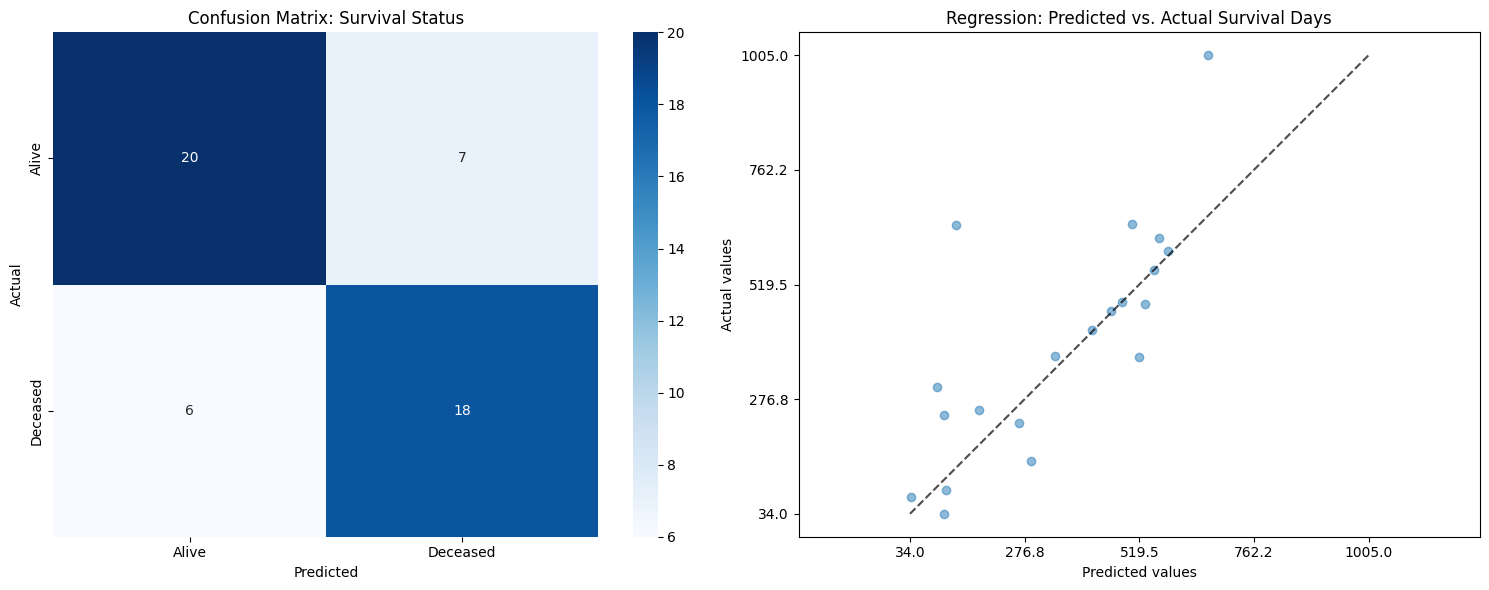

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, PredictionErrorDisplay

# Create a figure with two plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# 1. Confusion Matrix (Status)
cm = confusion_matrix(y_test_c, y_pred_c)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1)
ax1.set_title('Confusion Matrix: Survival Status')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')
ax1.set_xticklabels(['Alive', 'Deceased'])
ax1.set_yticklabels(['Alive', 'Deceased'])

# 2. Prediction Error Plot (Days)
# This shows how far off the day counts are from the 1-to-1 line
PredictionErrorDisplay.from_predictions(
    yr_test, y_pred_r, kind="actual_vs_predicted", ax=ax2, scatter_kwargs={"alpha": 0.5}
)
ax2.set_title('Regression: Predicted vs. Actual Survival Days')

plt.tight_layout()
plt.savefig('model_performance_summary.png')